# 08 - Comparaison Globale

## 1. Protocole de synthese et garde-fous

Cette synthese ne vise pas a conclure definitivement sur un meilleur modele unique.
Elle organise les artefacts canoniques pour formuler des hypotheses sur le classement confirmatoire,
le role du prétraitement, la stabilite inter-plis, le cout temporel et la complementarite potentielle
des erreurs en vue d'une future combinaison de modeles.

Regle de lecture :
- les lignes de la variante ajustée en `nested_cv` servent a la comparaison confirmatoire provisoire ;
- les variantes non ajustées restent exploratoires et servent a expliquer les signaux observes ;
- aucune conclusion finale n'est arretee dans ce notebook.


In [1]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

from src.config import RESULTS_DIR
from src.artifacts import charger_predictions_modele, charger_tableau_mesures_valides
from src.data import charger_donnees_modelisation
from src.evaluation import evaluer_dummy_classifier, matrice_confusion_normalisee, top_confusions
from src.notebook_support import (
    NOTEBOOK_MODEL_SPECS,
    charger_ou_generer_predictions_variante,
    construire_tableau_complementarite_erreurs,
    construire_tableau_corroboration_globale,
    construire_tableau_plis_tuned_global,
)
from src.plots import tracer_barres_comparaison, tracer_corroboration_globale, tracer_matrice_confusion, tracer_temps_vs_performance, tracer_top_confusions


## 2. Modèle de référence

Le `DummyClassifier` fournit le plancher commun a toutes les comparaisons de performance.


In [2]:
model_names = sorted(NOTEBOOK_MODEL_SPECS.keys())
OUTPUT_ROOT = RESULTS_DIR
split = charger_donnees_modelisation(output_root=OUTPUT_ROOT)
X, y, label_encoder = split.X_dev, split.y_dev, split.label_encoder
baseline_dummy = pd.DataFrame([evaluer_dummy_classifier(X, y)]).assign(
    selection_protocol="simple_cv",
    evaluation_stage="baseline",
    modele="dummy",
    variante="most_frequent",
)
display(baseline_dummy.round(4))


,val_accuracy_mean,val_accuracy_std,val_f1_macro_mean,val_f1_macro_std,train_accuracy_mean,train_f1_macro_mean,fit_time_mean,score_time_mean,elapsed_seconds,n_splits,modele,variante,selection_protocol,evaluation_stage
0,0.0063,0.0,0.0001,0.0,0.011,0.0002,0.0008,0.0019,0.0239,5,dummy,most_frequent,simple_cv,baseline


## 3. Résultats confirmatoires par modèle

Le tableau ci-dessous ne retient que les variantes ajustées evaluees en `validation croisée imbriquée`.
Il sert a etablir un classement confirmatoire provisoire et non une conclusion finale.


,modele,variante,val_f1_macro_mean,val_f1_macro_std,val_accuracy_mean,elapsed_seconds,selection_protocol
0,regression_logistique,tuned,0.9787,0.0198,0.9848,77.0500,nested_cv
1,svm,tuned,0.9756,0.0207,0.9823,56.4901,nested_cv
2,foret_aleatoire,tuned,0.9702,0.0140,0.9747,250.1117,nested_cv
3,mlp,tuned,0.9389,0.0322,0.9482,38.2547,nested_cv
4,perceptron,tuned,0.8085,0.0523,0.8409,29.7877,nested_cv
5,arbre_decision,tuned,0.4295,0.0546,0.4610,11.4742,nested_cv


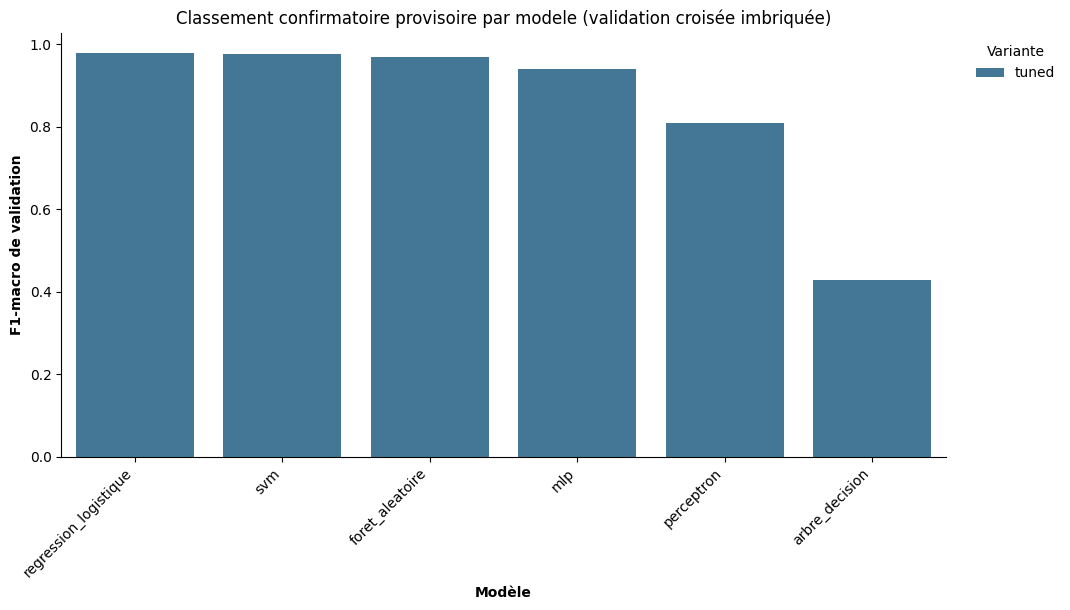

In [3]:
mesures = charger_tableau_mesures_valides(modeles=model_names, metrics_dir=OUTPUT_ROOT)
best_tuned = (
    mesures.loc[mesures["evaluation_stage"] == "tuned"]
    .sort_values(["val_f1_macro_mean", "val_accuracy_mean"], ascending=False)
    .reset_index(drop=True)
)
if best_tuned["modele"].nunique() != len(model_names):
    raise RuntimeError(
        "Synthese globale bloquee: tous les modèles doivent disposer d'un résultat ajusté valide avant le classement provisoire."
    )

display(best_tuned[[
    "modele",
    "variante",
    "val_f1_macro_mean",
    "val_f1_macro_std",
    "val_accuracy_mean",
    "elapsed_seconds",
    "selection_protocol",
]].round(4))
tracer_barres_comparaison(
    best_tuned,
    metrique="val_f1_macro_mean",
    titre="Classement confirmatoire provisoire par modele (validation croisée imbriquée)",
)
plt.show()


## 4. Variantes exploratoires et coût

Cette section se limite a deux lectures complementaires :
- un graphe confirmatoire `temps contre performance` sur les seules lignes de la variante ajustée ;
- un tableau exploratoire des meilleures variantes non ajustées par modele, pour quantifier
  l'effet du prétraitement et du tuning avant toute conclusion.


,modele,variante,val_f1_macro_mean,val_accuracy_mean,generalization_gap_f1_macro,delta_f1_vs_default,elapsed_seconds
4,regression_logistique,scaled_only,0.9798,0.9861,0.0202,0.7207,8.0955
1,foret_aleatoire,default,0.9764,0.9785,0.0236,0.0000,9.1642
5,svm,scaled_only,0.9712,0.9785,0.0266,0.1323,2.4501
2,mlp,scaled_only,0.9389,0.9482,0.0552,0.7748,2.0081
3,perceptron,scaled_only,0.8228,0.8460,0.1732,0.1248,0.6031
0,arbre_decision,default,0.5809,0.6174,0.4191,0.0000,1.0411


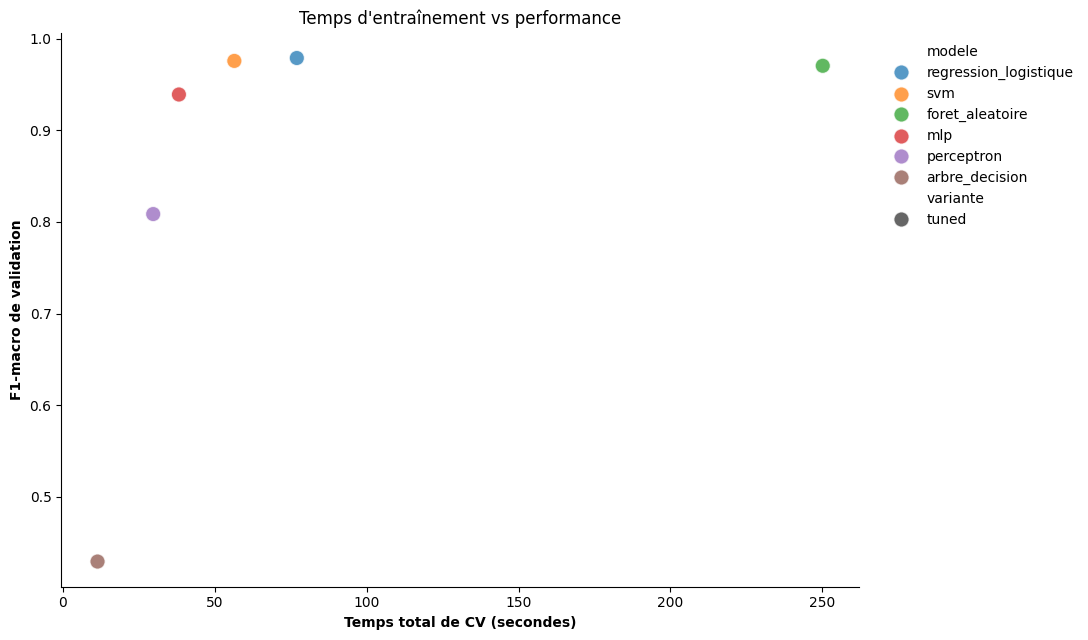

In [4]:
tableau_exploratoire = (
    mesures.loc[mesures["evaluation_stage"] != "tuned"]
    .sort_values(["modele", "val_f1_macro_mean"], ascending=[True, False])
    .reset_index(drop=True)
)

best_exploratoire = (
    tableau_exploratoire
    .sort_values(["modele", "val_f1_macro_mean"], ascending=[True, False])
    .groupby("modele", as_index=False)
    .head(1)
    .copy()
)

defaults = (
    tableau_exploratoire.loc[tableau_exploratoire["variante"] == "default", [
        "modele",
        "val_f1_macro_mean",
        "val_accuracy_mean",
    ]]
    .rename(columns={
        "val_f1_macro_mean": "default_f1_macro",
        "val_accuracy_mean": "default_accuracy",
    })
)

best_exploratoire = best_exploratoire.merge(defaults, on="modele", how="left")
best_exploratoire["delta_f1_vs_default"] = (
    best_exploratoire["val_f1_macro_mean"] - best_exploratoire["default_f1_macro"]
)

display(best_exploratoire[[
    "modele",
    "variante",
    "val_f1_macro_mean",
    "val_accuracy_mean",
    "generalization_gap_f1_macro",
    "delta_f1_vs_default",
    "elapsed_seconds",
]].sort_values("val_f1_macro_mean", ascending=False).round(4))

tracer_temps_vs_performance(
    best_tuned,
    metrique="val_f1_macro_mean",
)
plt.show()


### Stabilite inter-plis des meilleurs modeles

Le tableau ci-dessous reconstitue les scores par pli externe pour les principaux candidats `tuned`.
Il sert a juger la stabilite relative des meilleurs modeles sans transformer les ecarts fins en conclusion definitive.


In [5]:
top_models = best_tuned.head(3)["modele"].tolist()
predictions_top = {modele: charger_predictions_modele(modele, "tuned", root=OUTPUT_ROOT) for modele in top_models}
tableau_plis_tuned = construire_tableau_plis_tuned_global(
    X,
    y,
    predictions_top,
    n_splits=int(best_tuned.iloc[0]["n_splits"]),
)
display(tableau_plis_tuned.pivot(index="fold", columns="modele", values="val_f1_macro").round(4))
display(tableau_plis_tuned.pivot(index="fold", columns="modele", values="val_accuracy").round(4))


modele,foret_aleatoire,regression_logistique,svm
fold,,,
1,0.9650,0.9865,0.9879
2,0.9811,0.9879,0.9758
3,0.9636,0.9704,0.9690
4,0.9535,0.9488,0.9451
5,0.9879,1.0000,1.0000


modele,foret_aleatoire,regression_logistique,svm
fold,,,
1,0.9686,0.9937,0.9937
2,0.9811,0.9874,0.9748
3,0.9684,0.9810,0.9810
4,0.9684,0.9620,0.9620
5,0.9873,1.0000,1.0000


## 5. Diagnostics multiclasses du meilleur modele

Le modele en tete du classement provisoire est ici traite comme **candidat confirmatoire courant**.
Cette section sert uniquement a documenter les erreurs multiclasses les plus saillantes du candidat
actuellement le mieux classe, sans transformer ce rang provisoire en conclusion finale.


,candidat_confirmatoire_courant
0,regression_logistique


,classe_vraie,classe_predite,nombre_erreurs
0,Eucalyptus_Neglecta,Eucalyptus_Glaucescens,1
1,Eucalyptus_Neglecta,Eucalyptus_Urnigera,1
2,Eucalyptus_Urnigera,Quercus_Infectoria_sub,1
3,Lithocarpus_Edulis,Lithocarpus_Cleistocarpus,1
4,Olea_Europaea,Salix_Intergra,1
5,Populus_Adenopoda,Cytisus_Battandieri,1
6,Prunus_X_Shmittii,Morus_Nigra,1
7,Quercus_Castaneifolia,Quercus_Kewensis,1
8,Quercus_Infectoria_sub,Cercis_Siliquastrum,1
9,Quercus_Palustris,Quercus_Shumardii,1


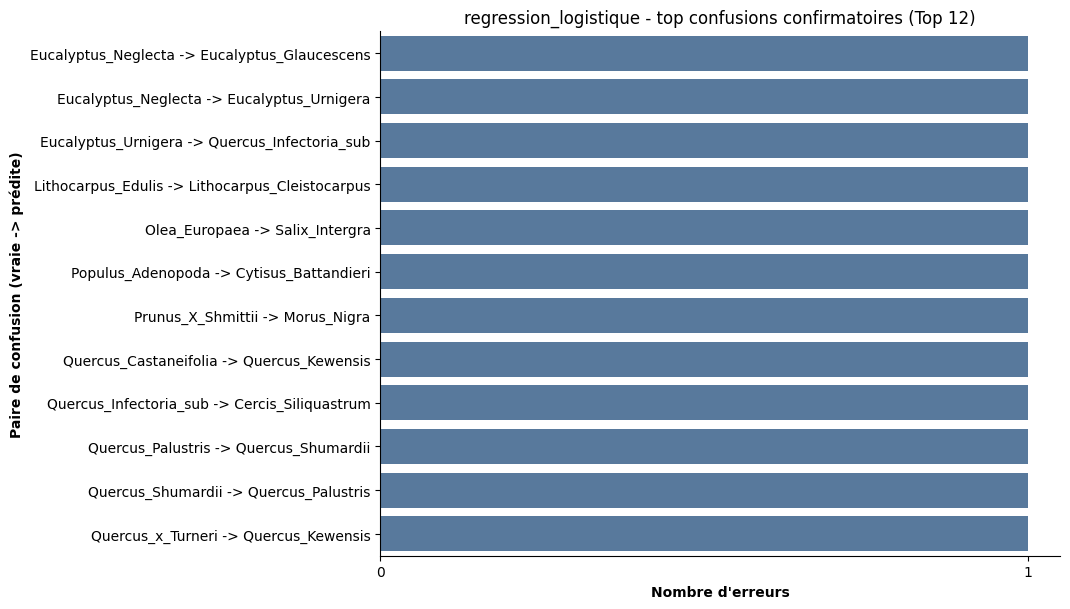

In [6]:
candidat_courant = best_tuned.iloc[0]["modele"]
candidat_predictions = charger_predictions_modele(candidat_courant, "tuned", root=OUTPUT_ROOT)
candidat_confusions = top_confusions(
    candidat_predictions["y_true"].to_numpy(),
    candidat_predictions["y_pred"].to_numpy(),
    label_encoder=label_encoder,
    top_n=15,
)
display(pd.DataFrame([{"candidat_confirmatoire_courant": candidat_courant}]))
display(candidat_confusions.round(4))
if not candidat_confusions.empty:
    tracer_top_confusions(
        candidat_confusions,
        top_n=min(15, len(candidat_confusions)),
        titre=f"{candidat_courant} - top confusions confirmatoires",
    )
    plt.show()


### Matrices de confusion par modele et variante

Les matrices ci-dessous servent a comparer les profils d'erreurs a travers tous les modeles et toutes les variantes publiees.
- pour la variante ajustée, les prédictions proviennent des artefacts `hors pli` de la `validation croisée imbriquée` ;
- pour les variantes non ajustées, les prédictions sont reconstruites en `validation croisée simple` avec le protocole partage.

Cette section reste descriptive : elle documente les erreurs sans conclure sur une superiorite definitive.


### arbre_decision

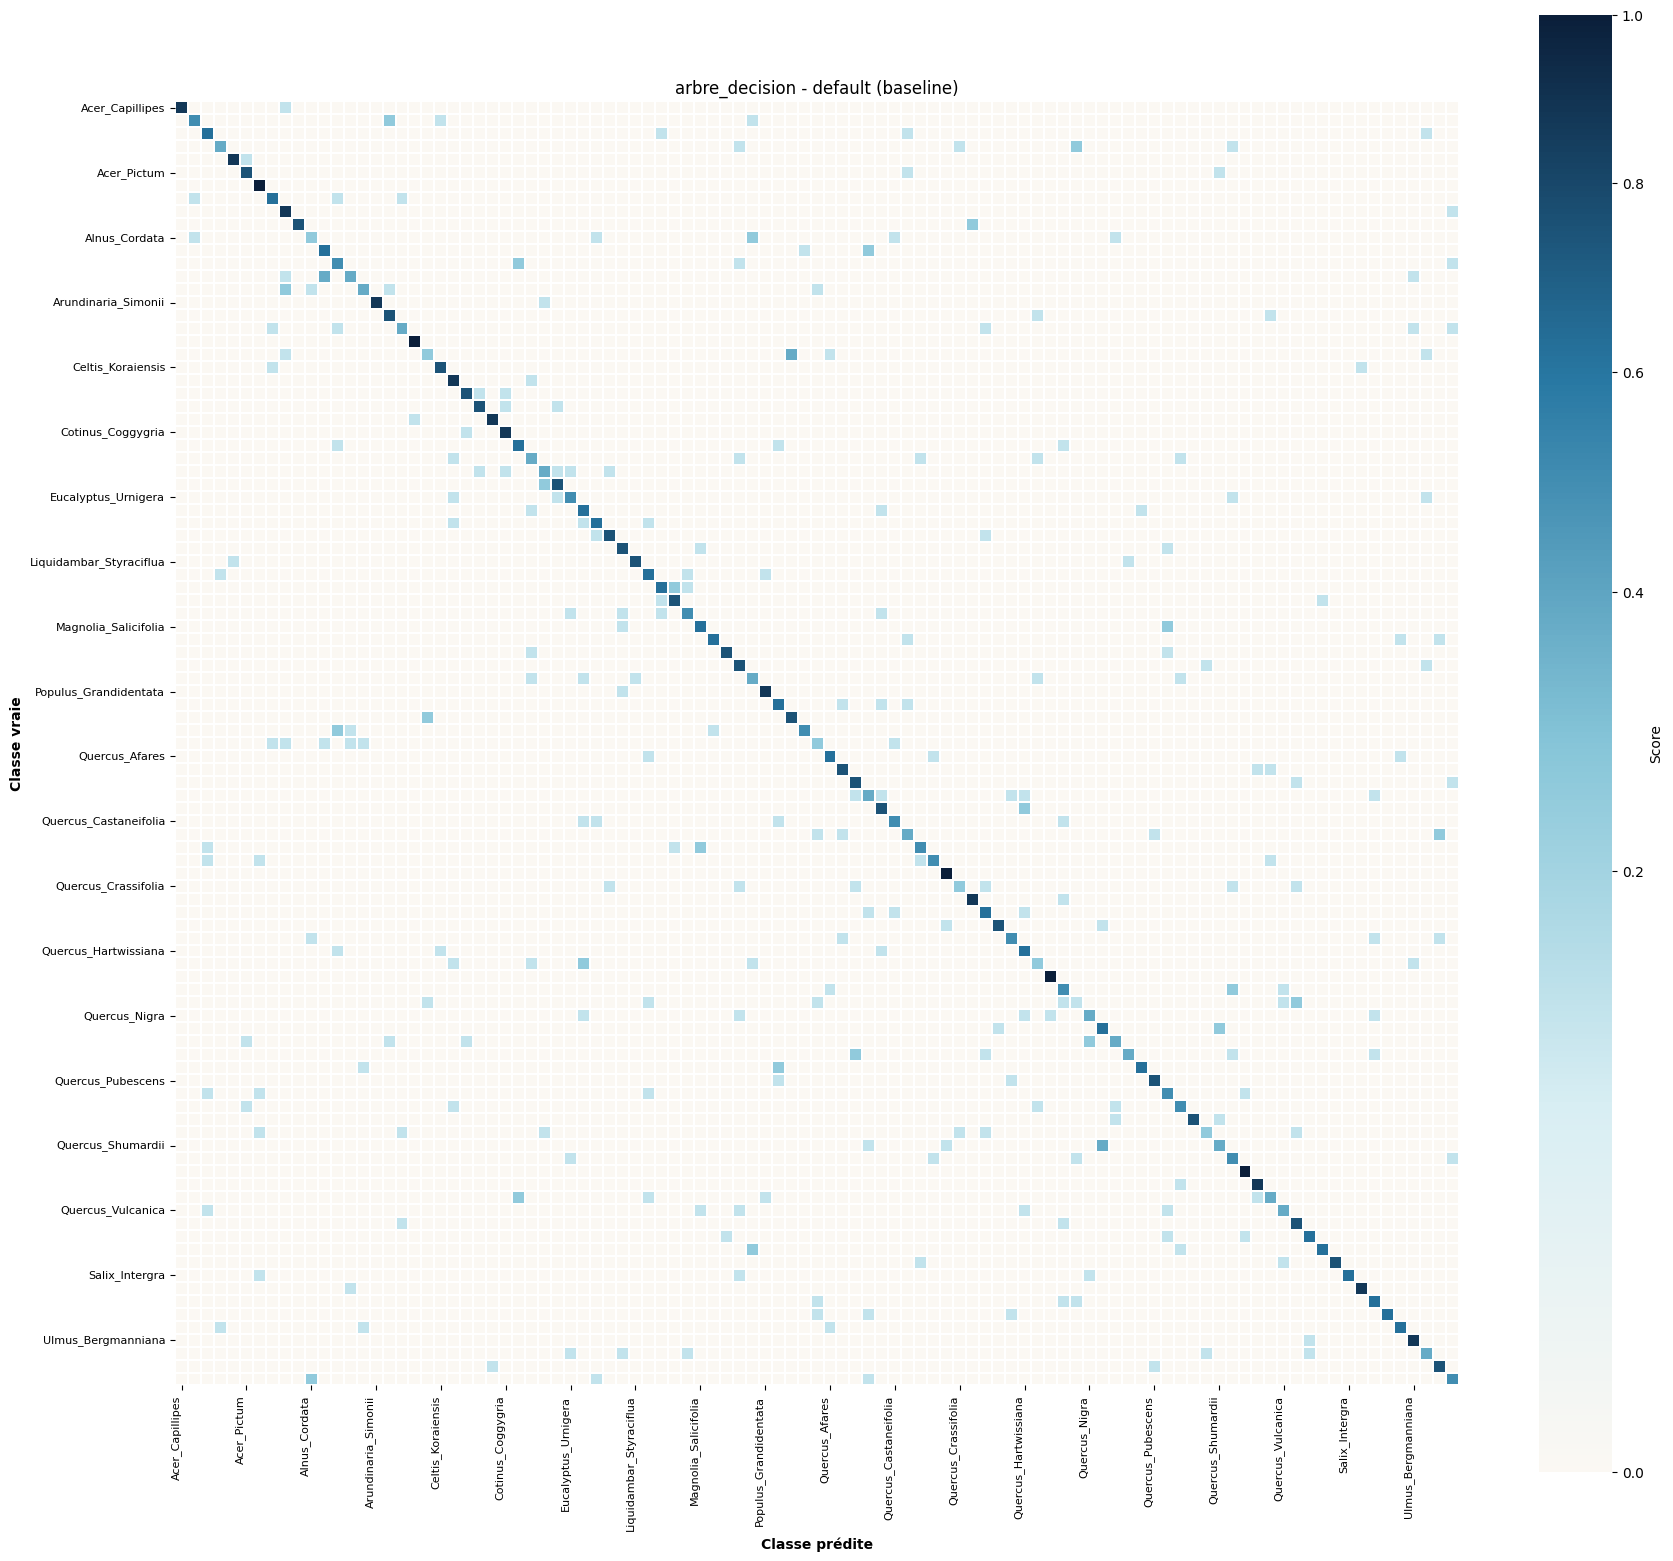

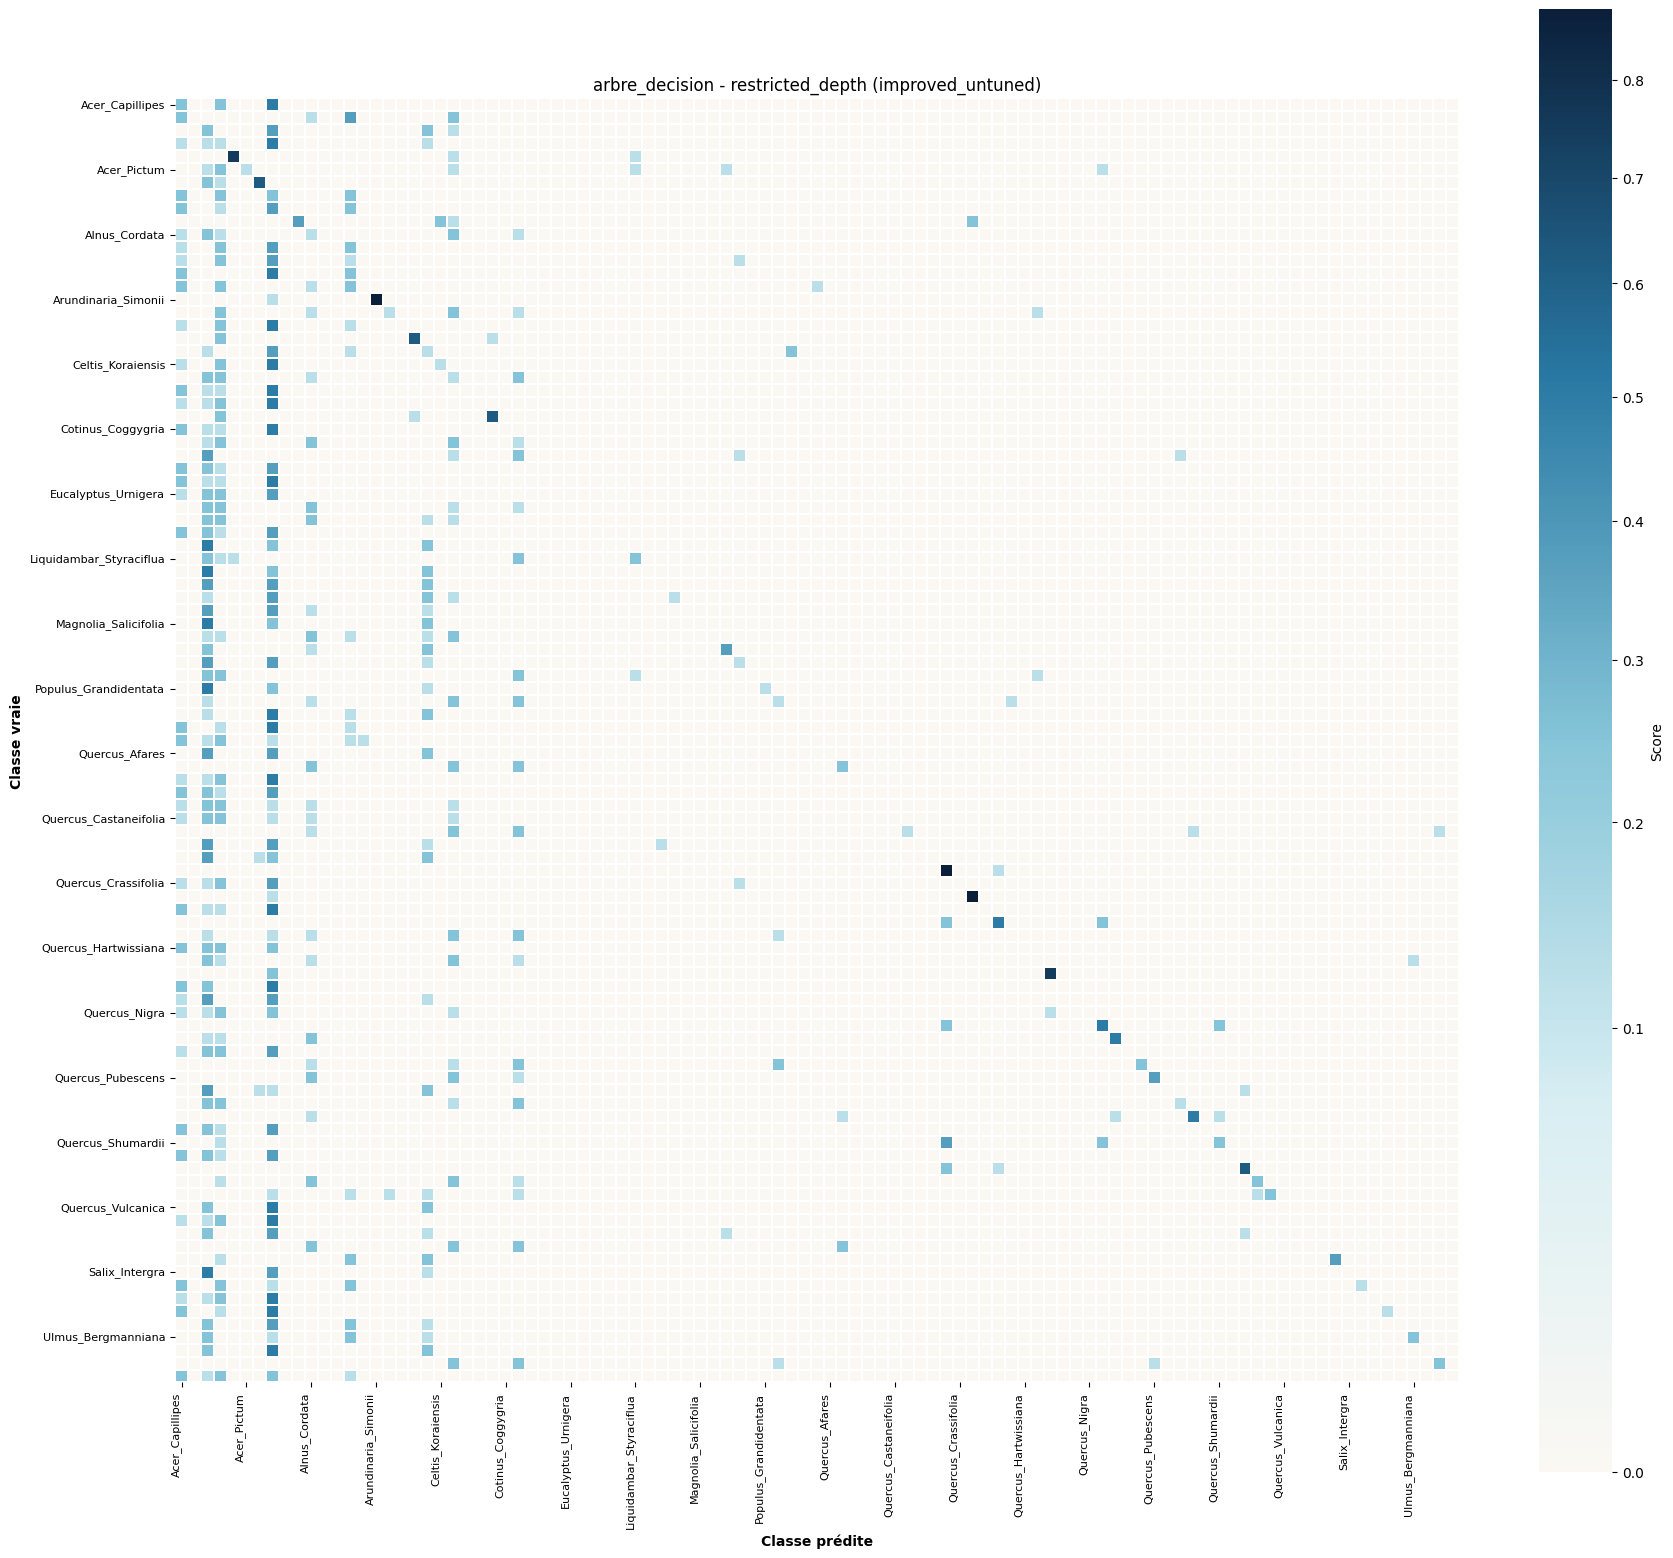

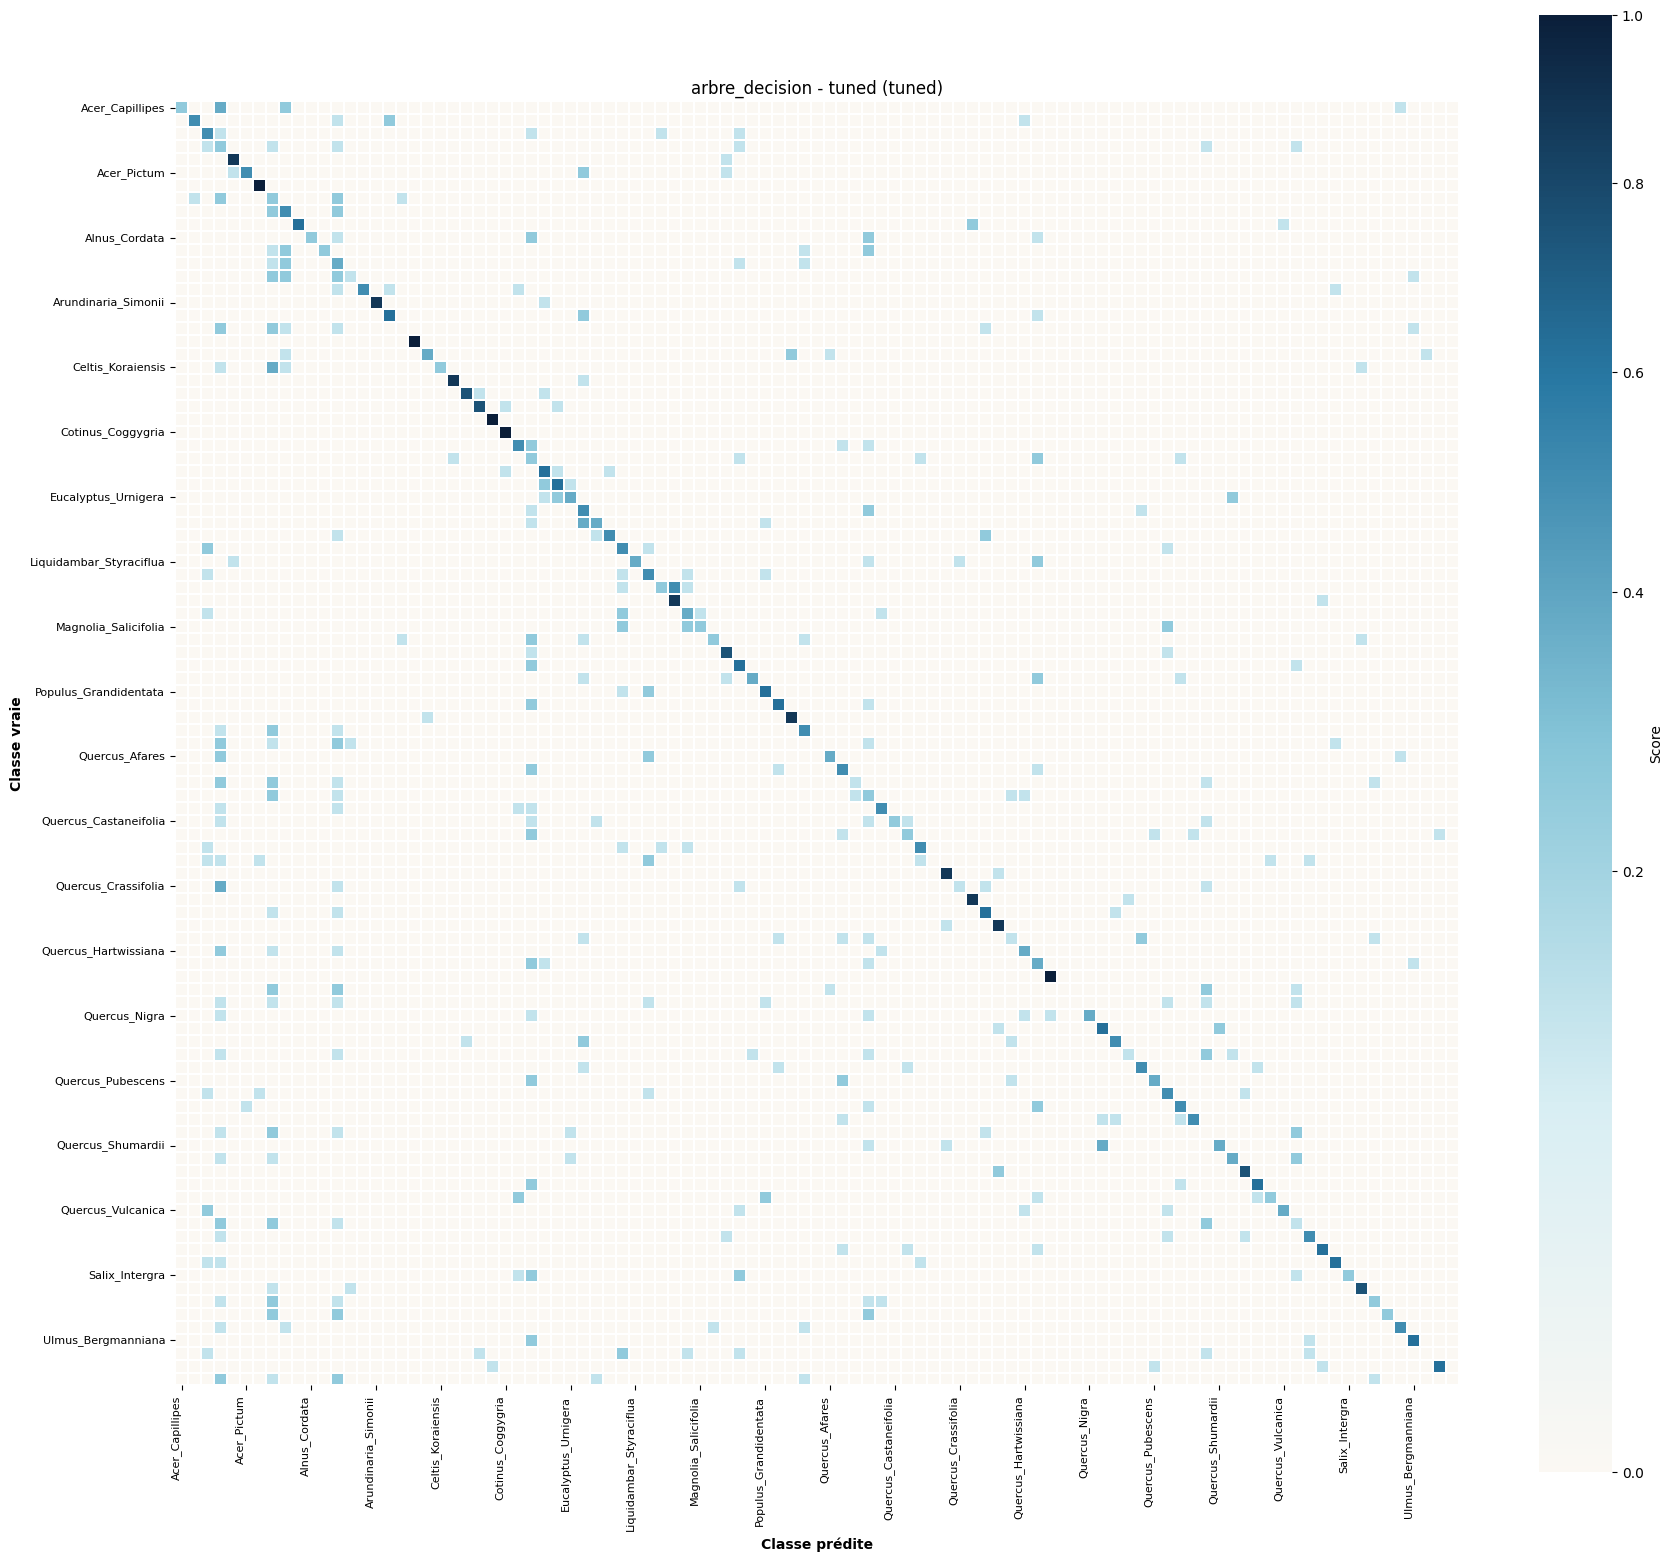

### foret_aleatoire

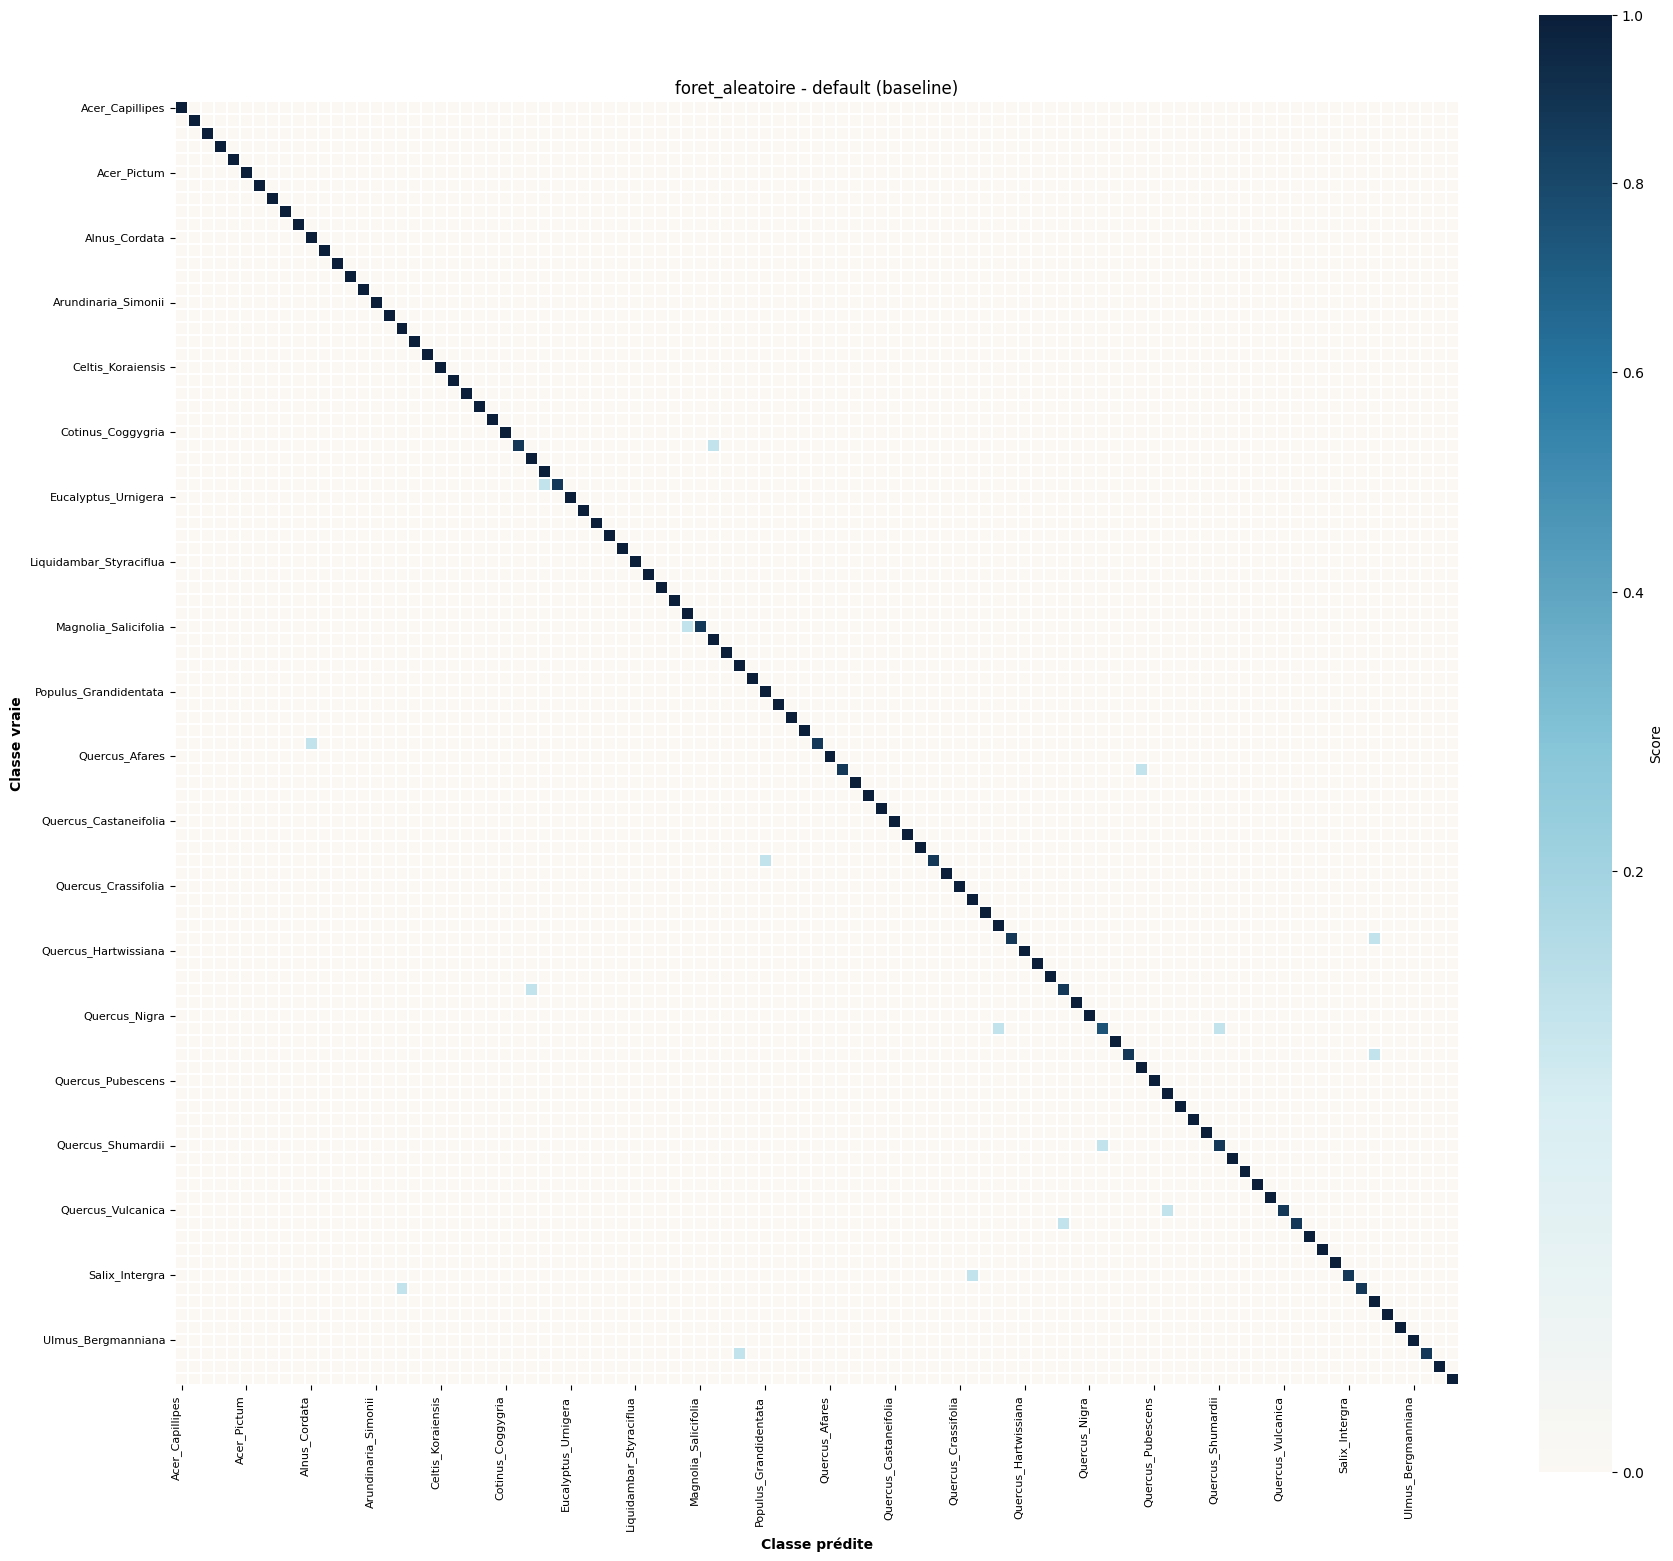

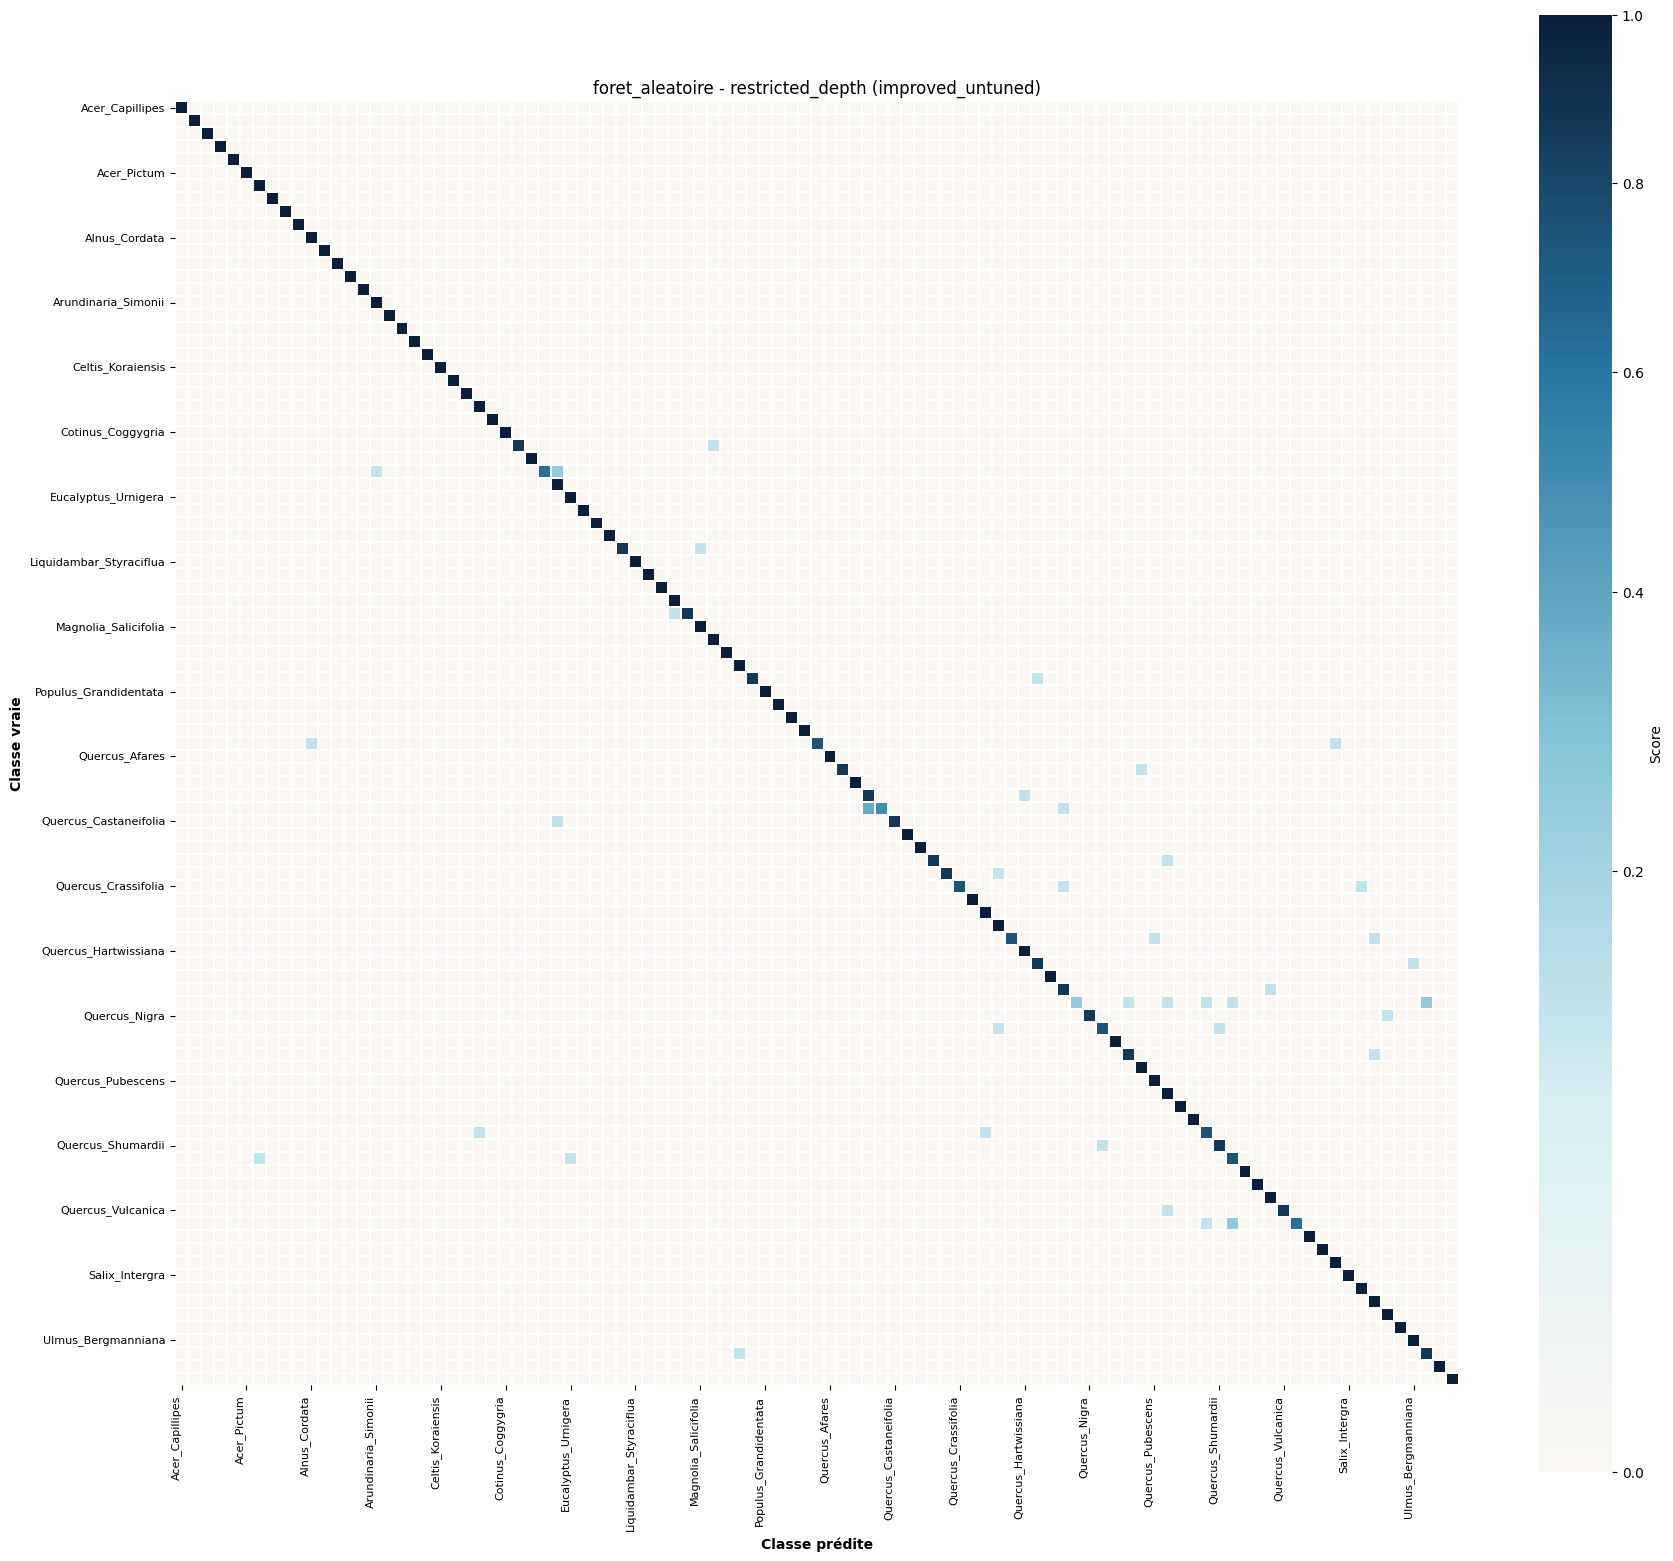

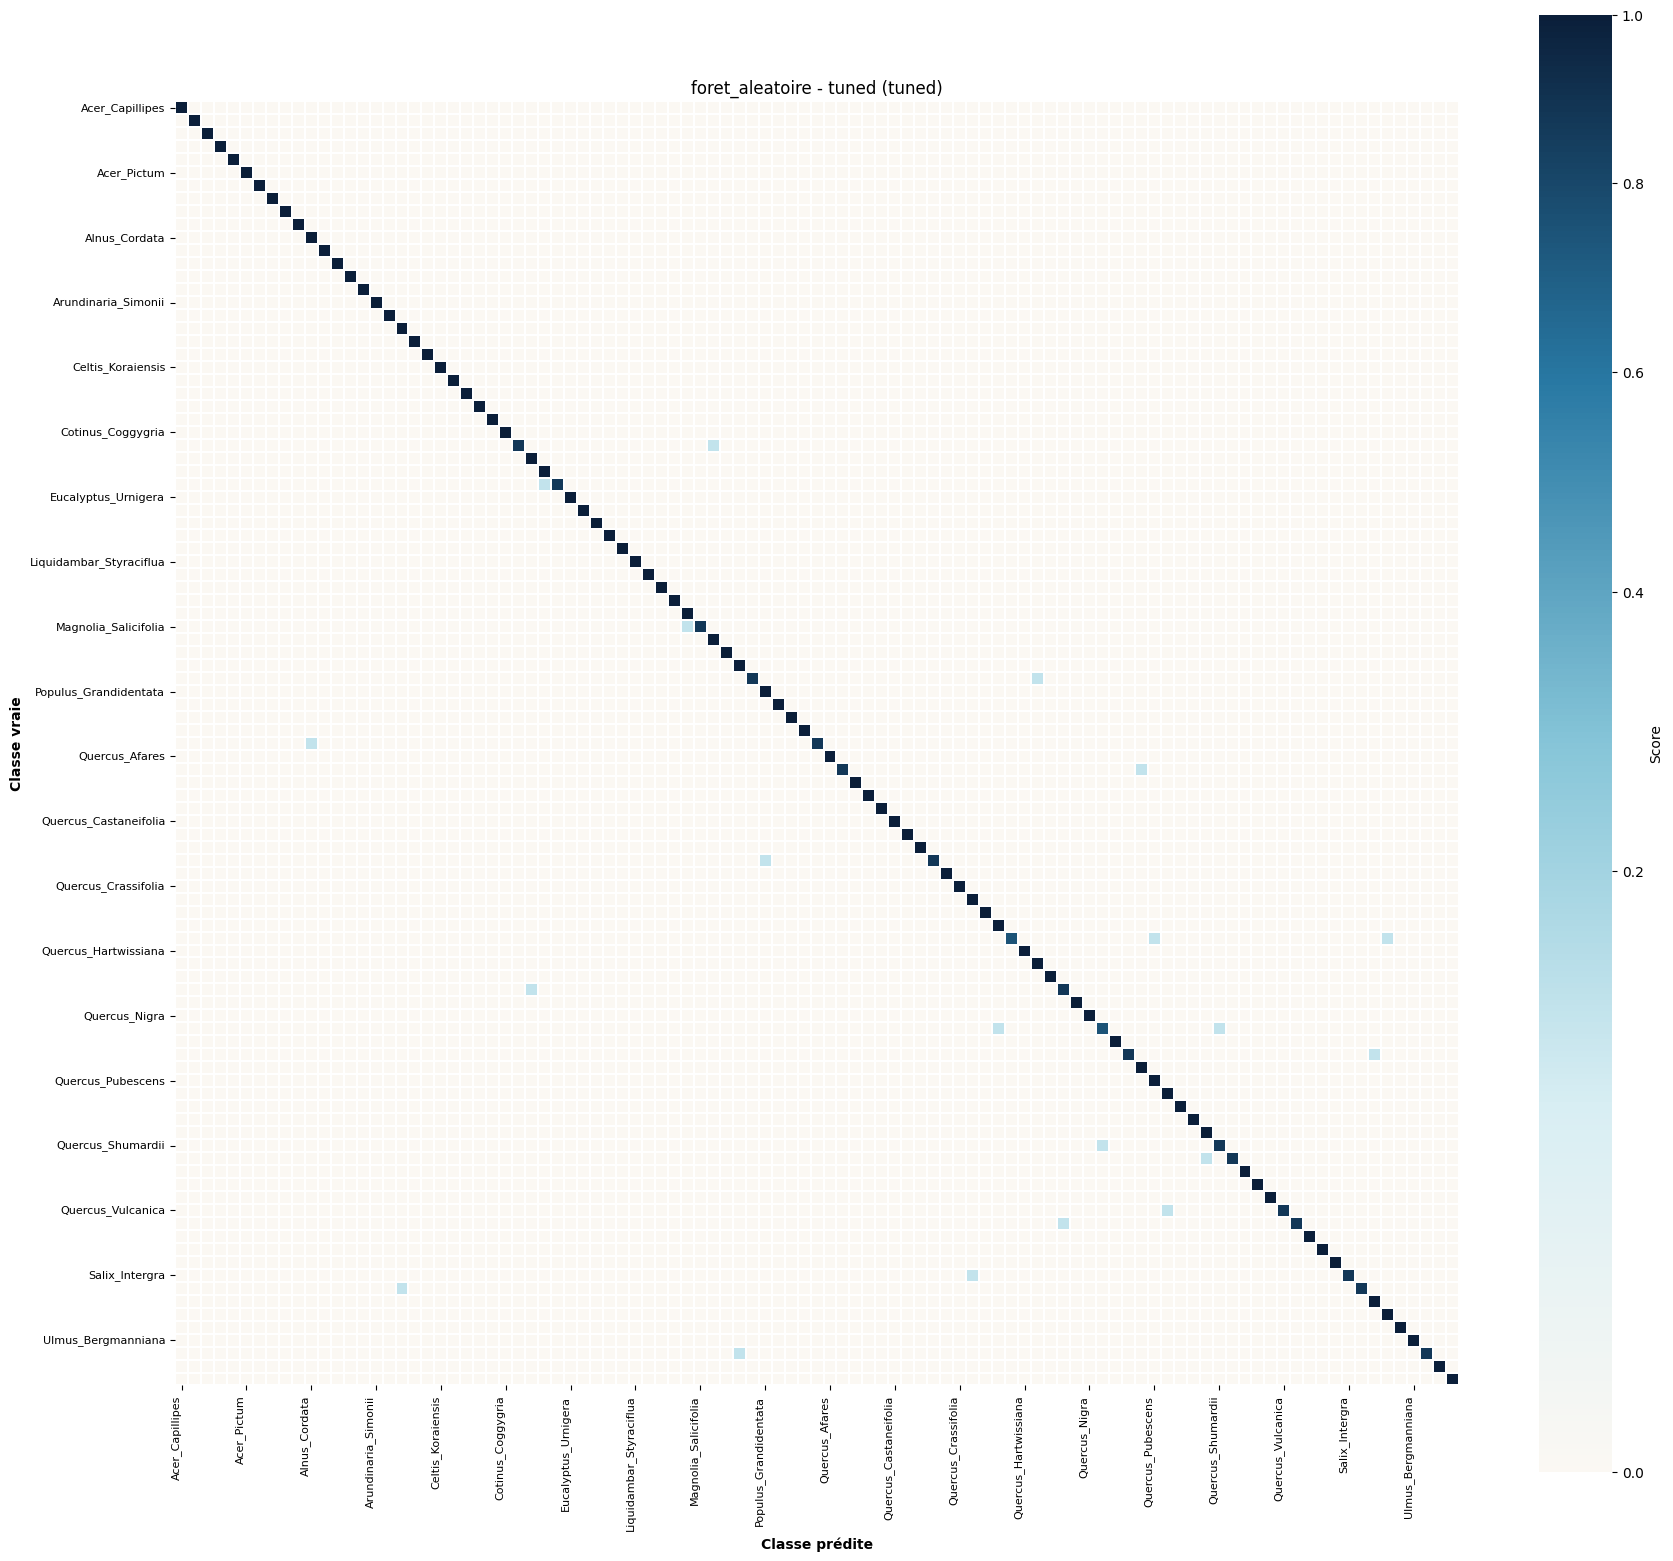

### mlp

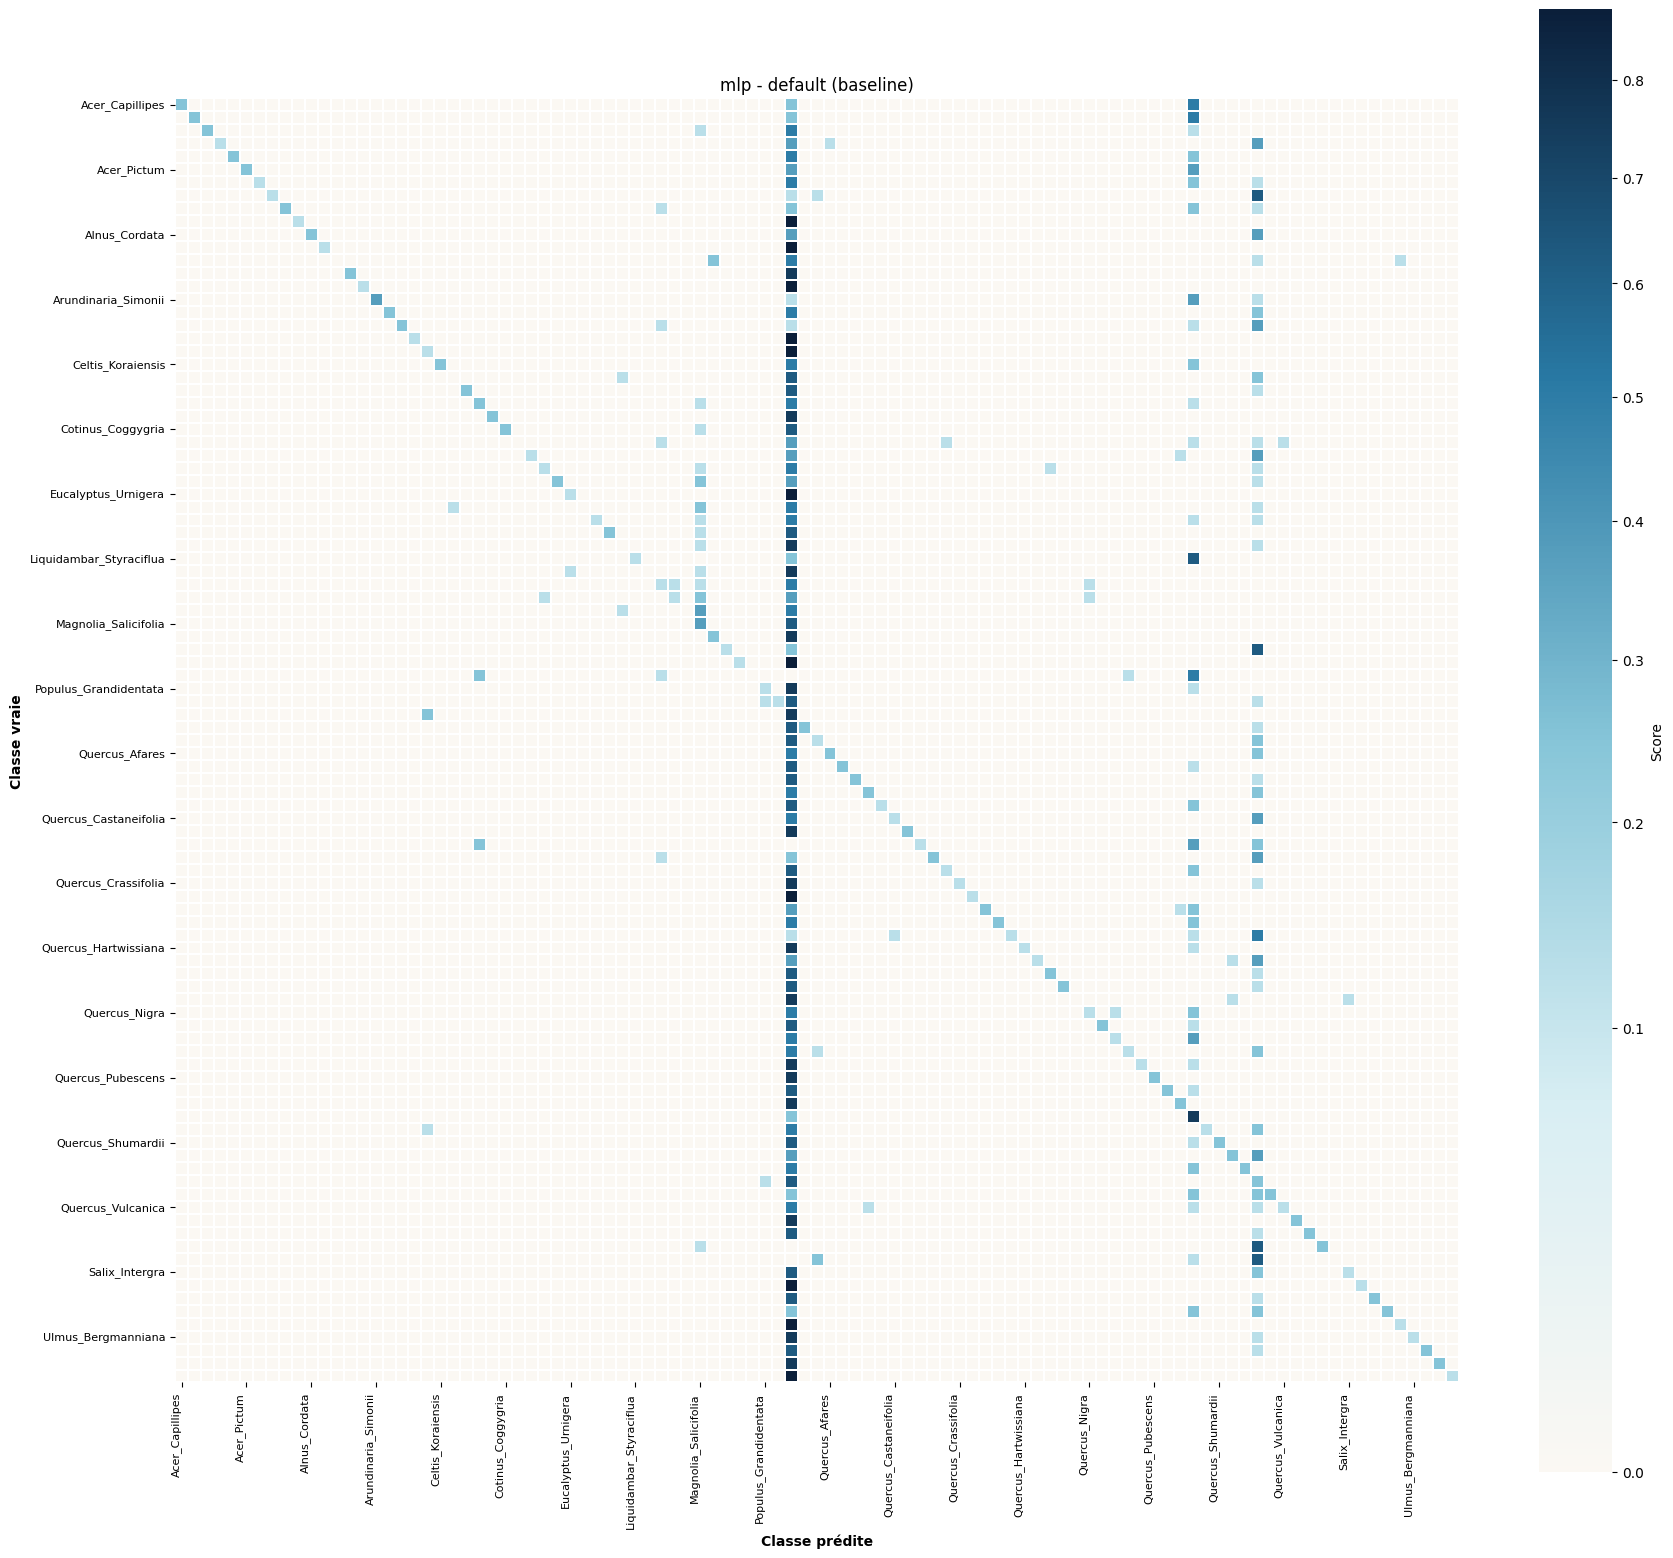

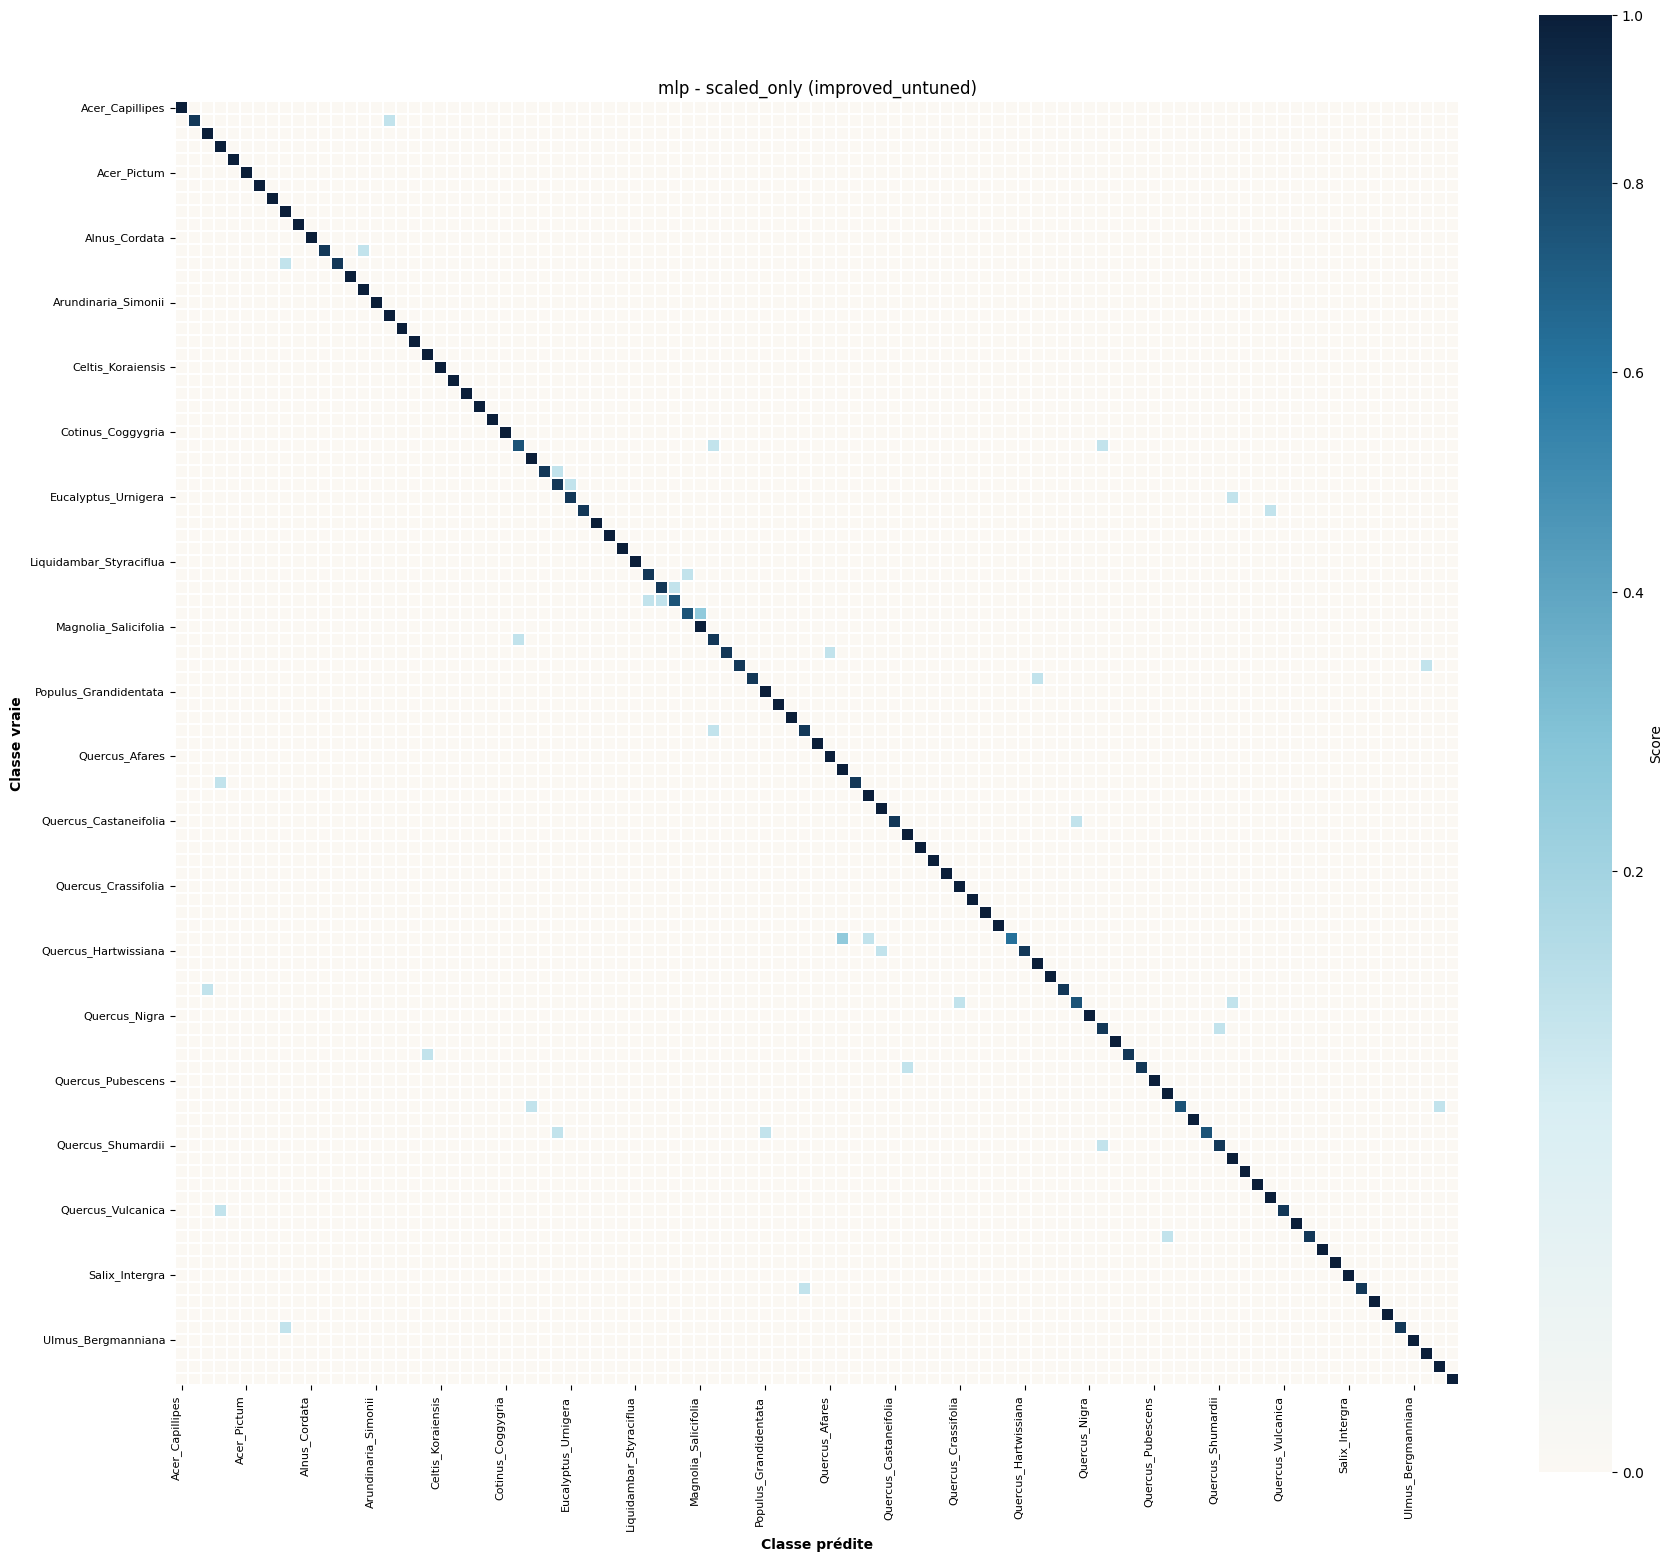

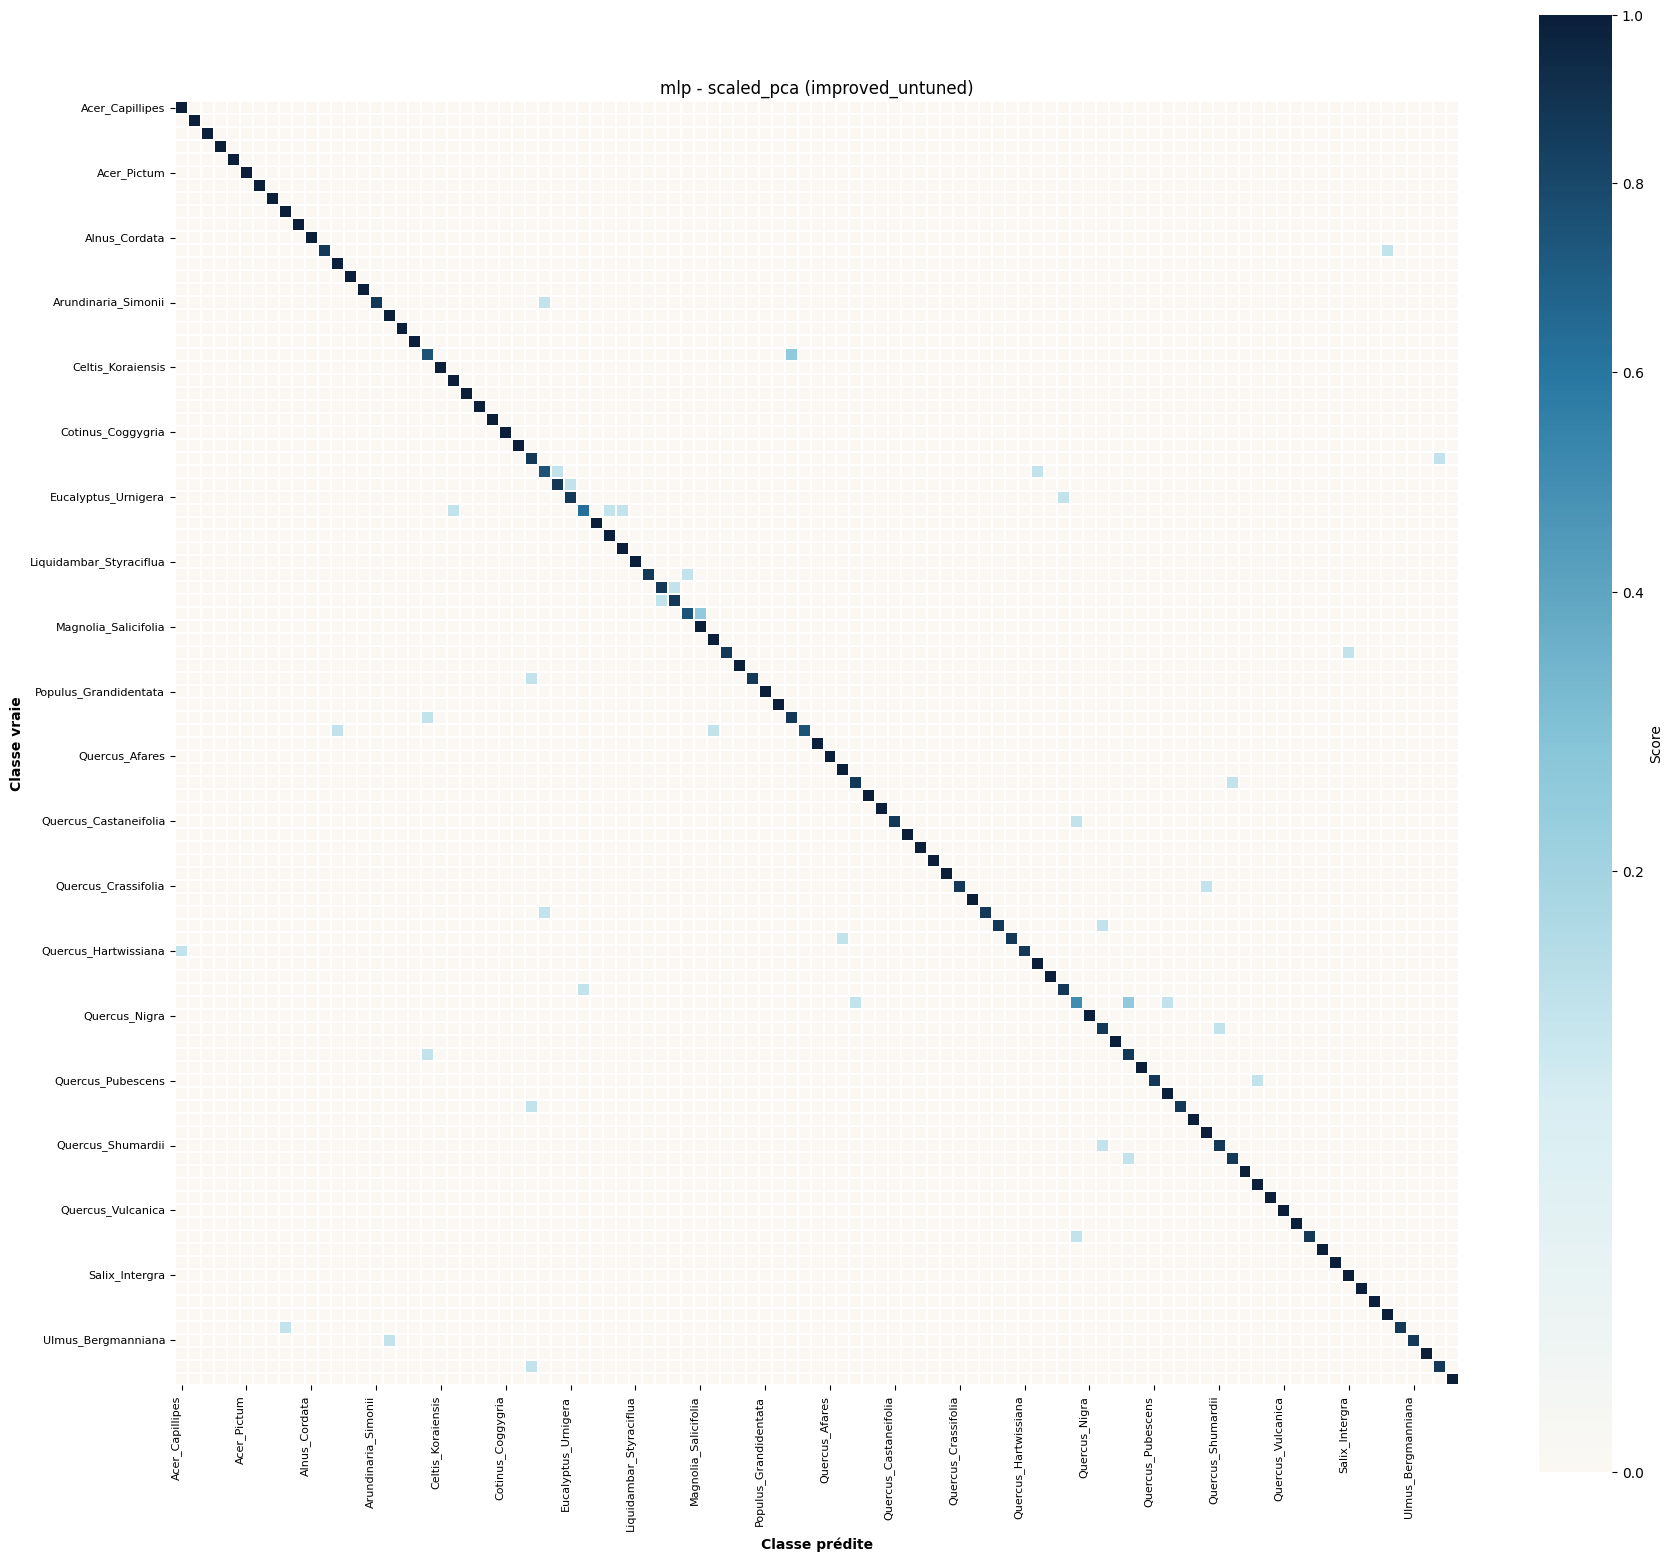

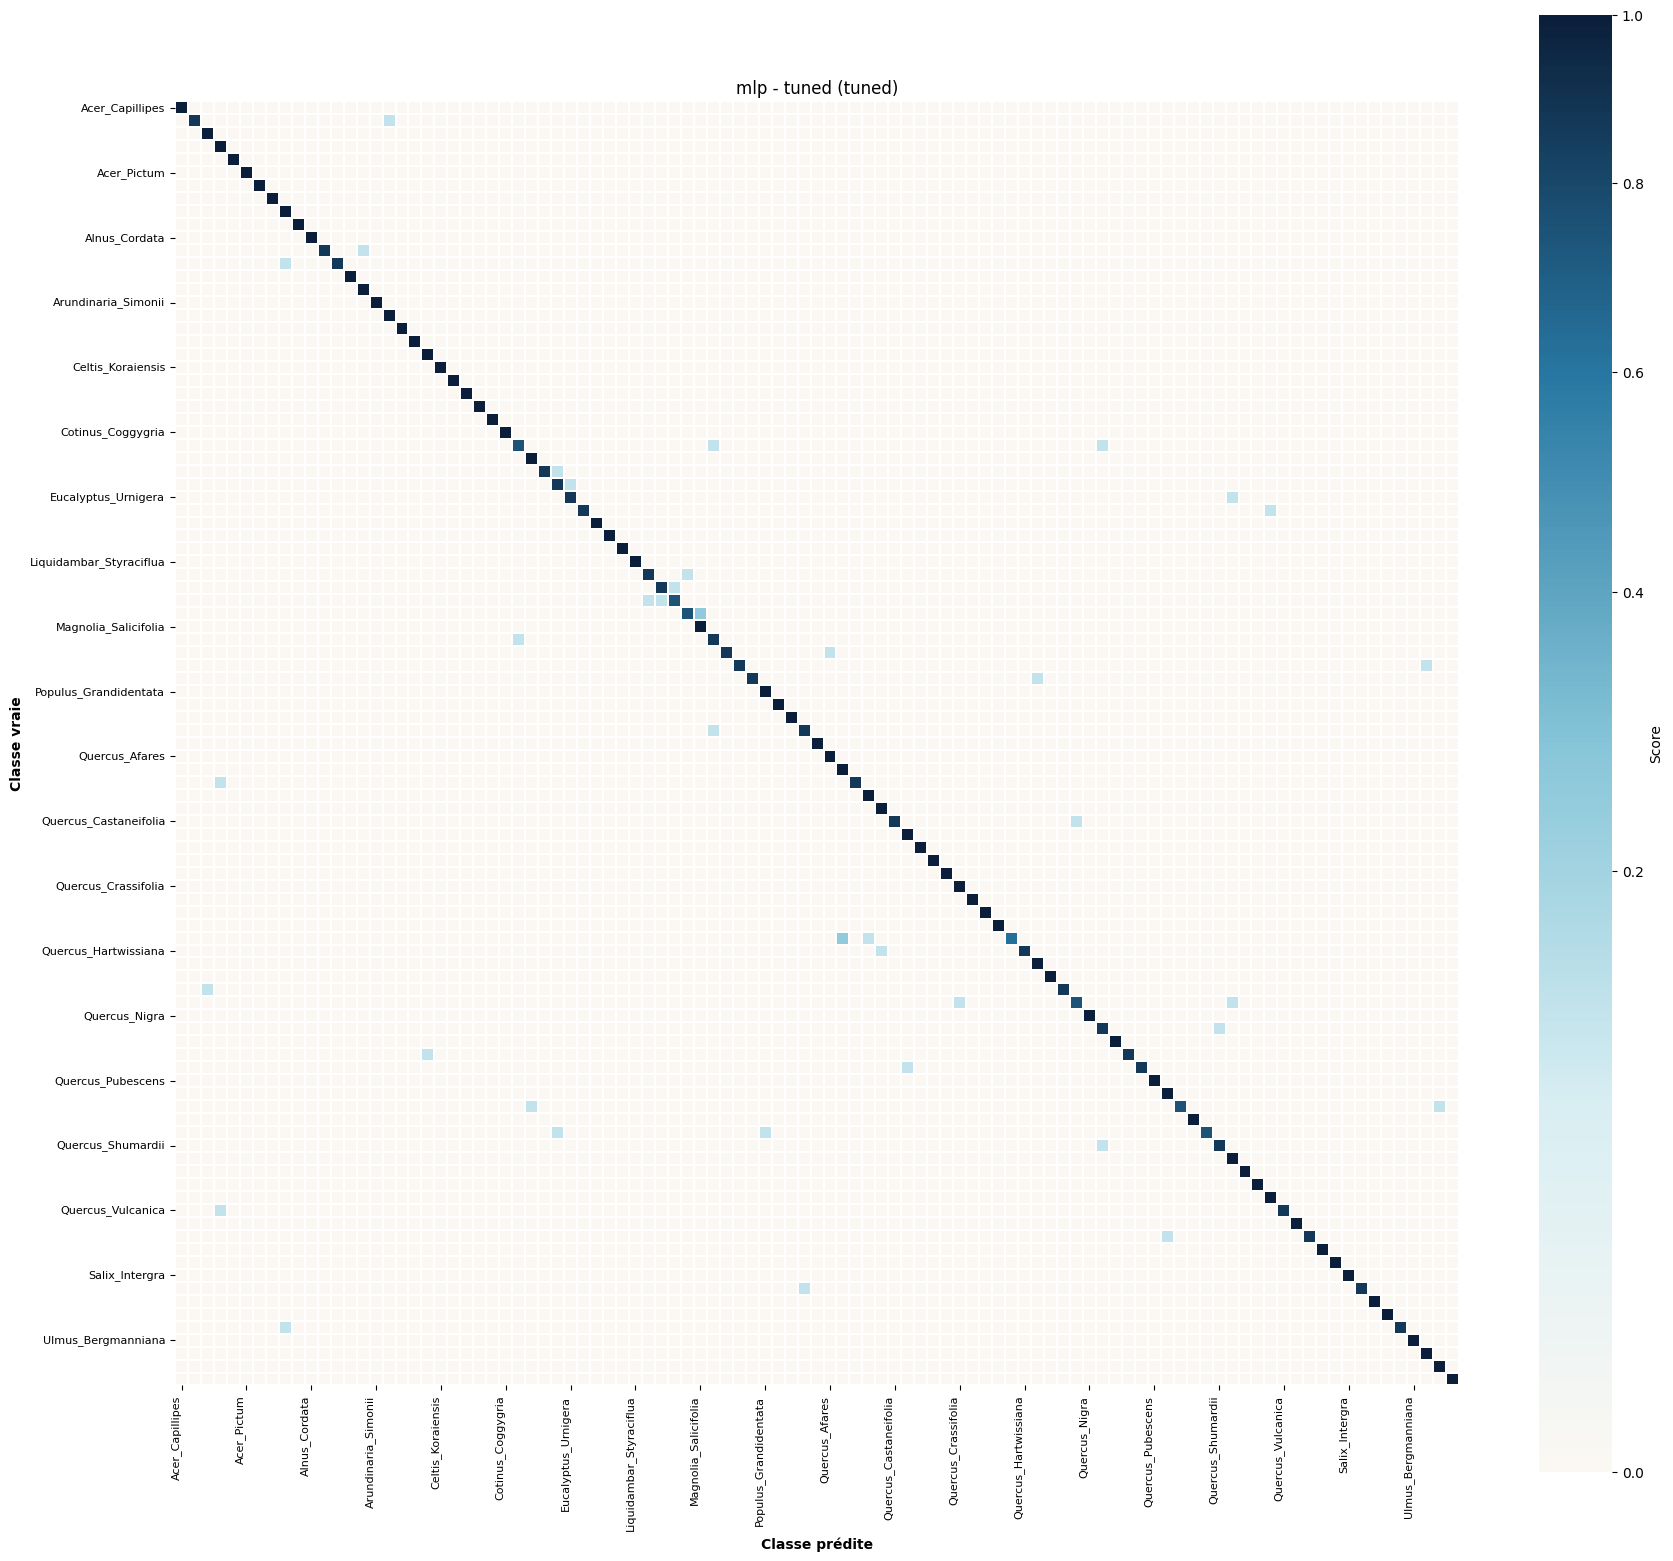

### perceptron

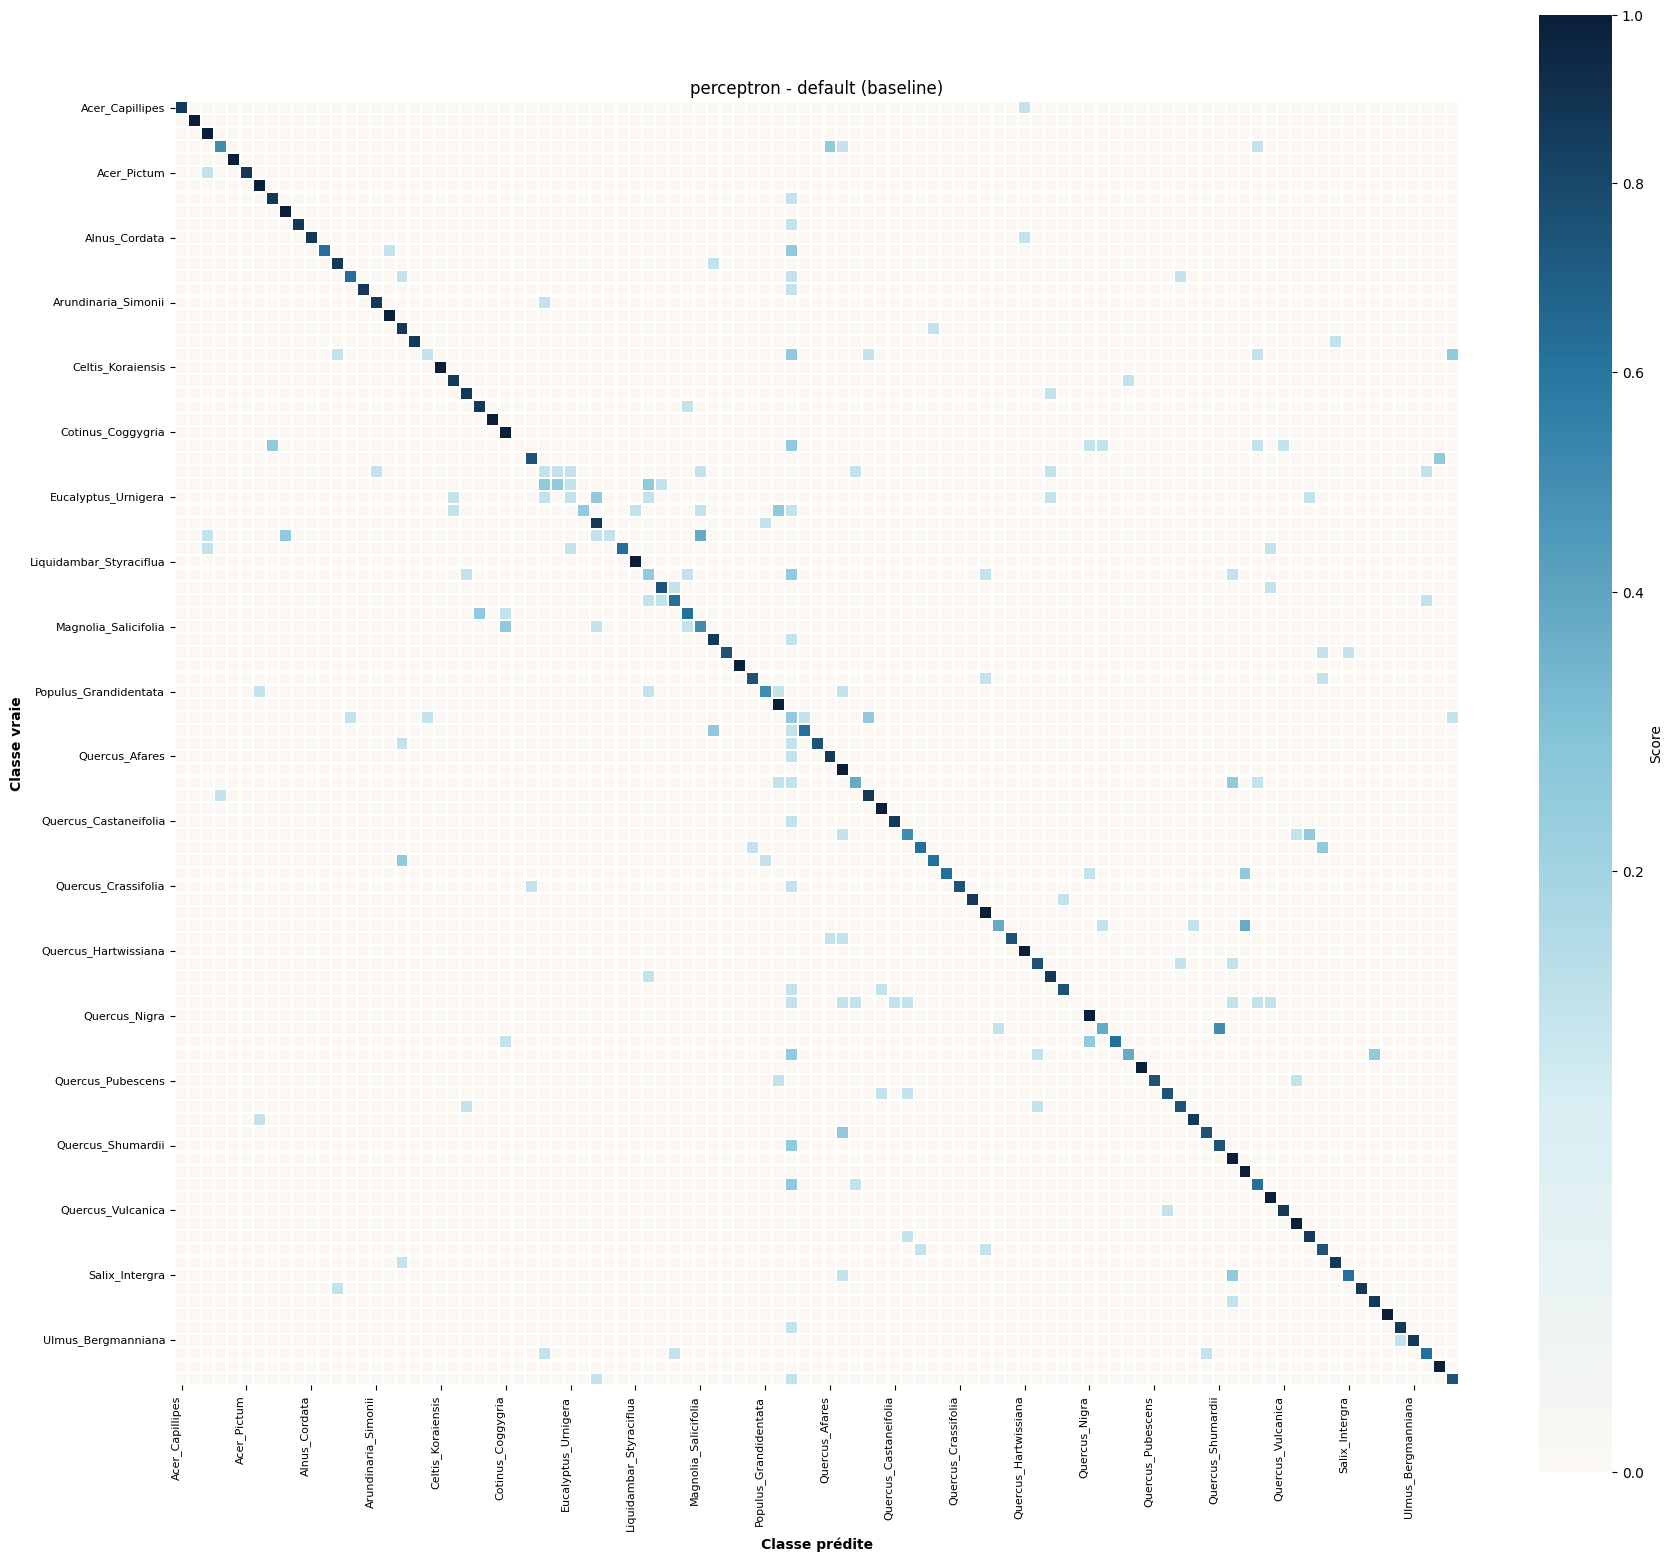

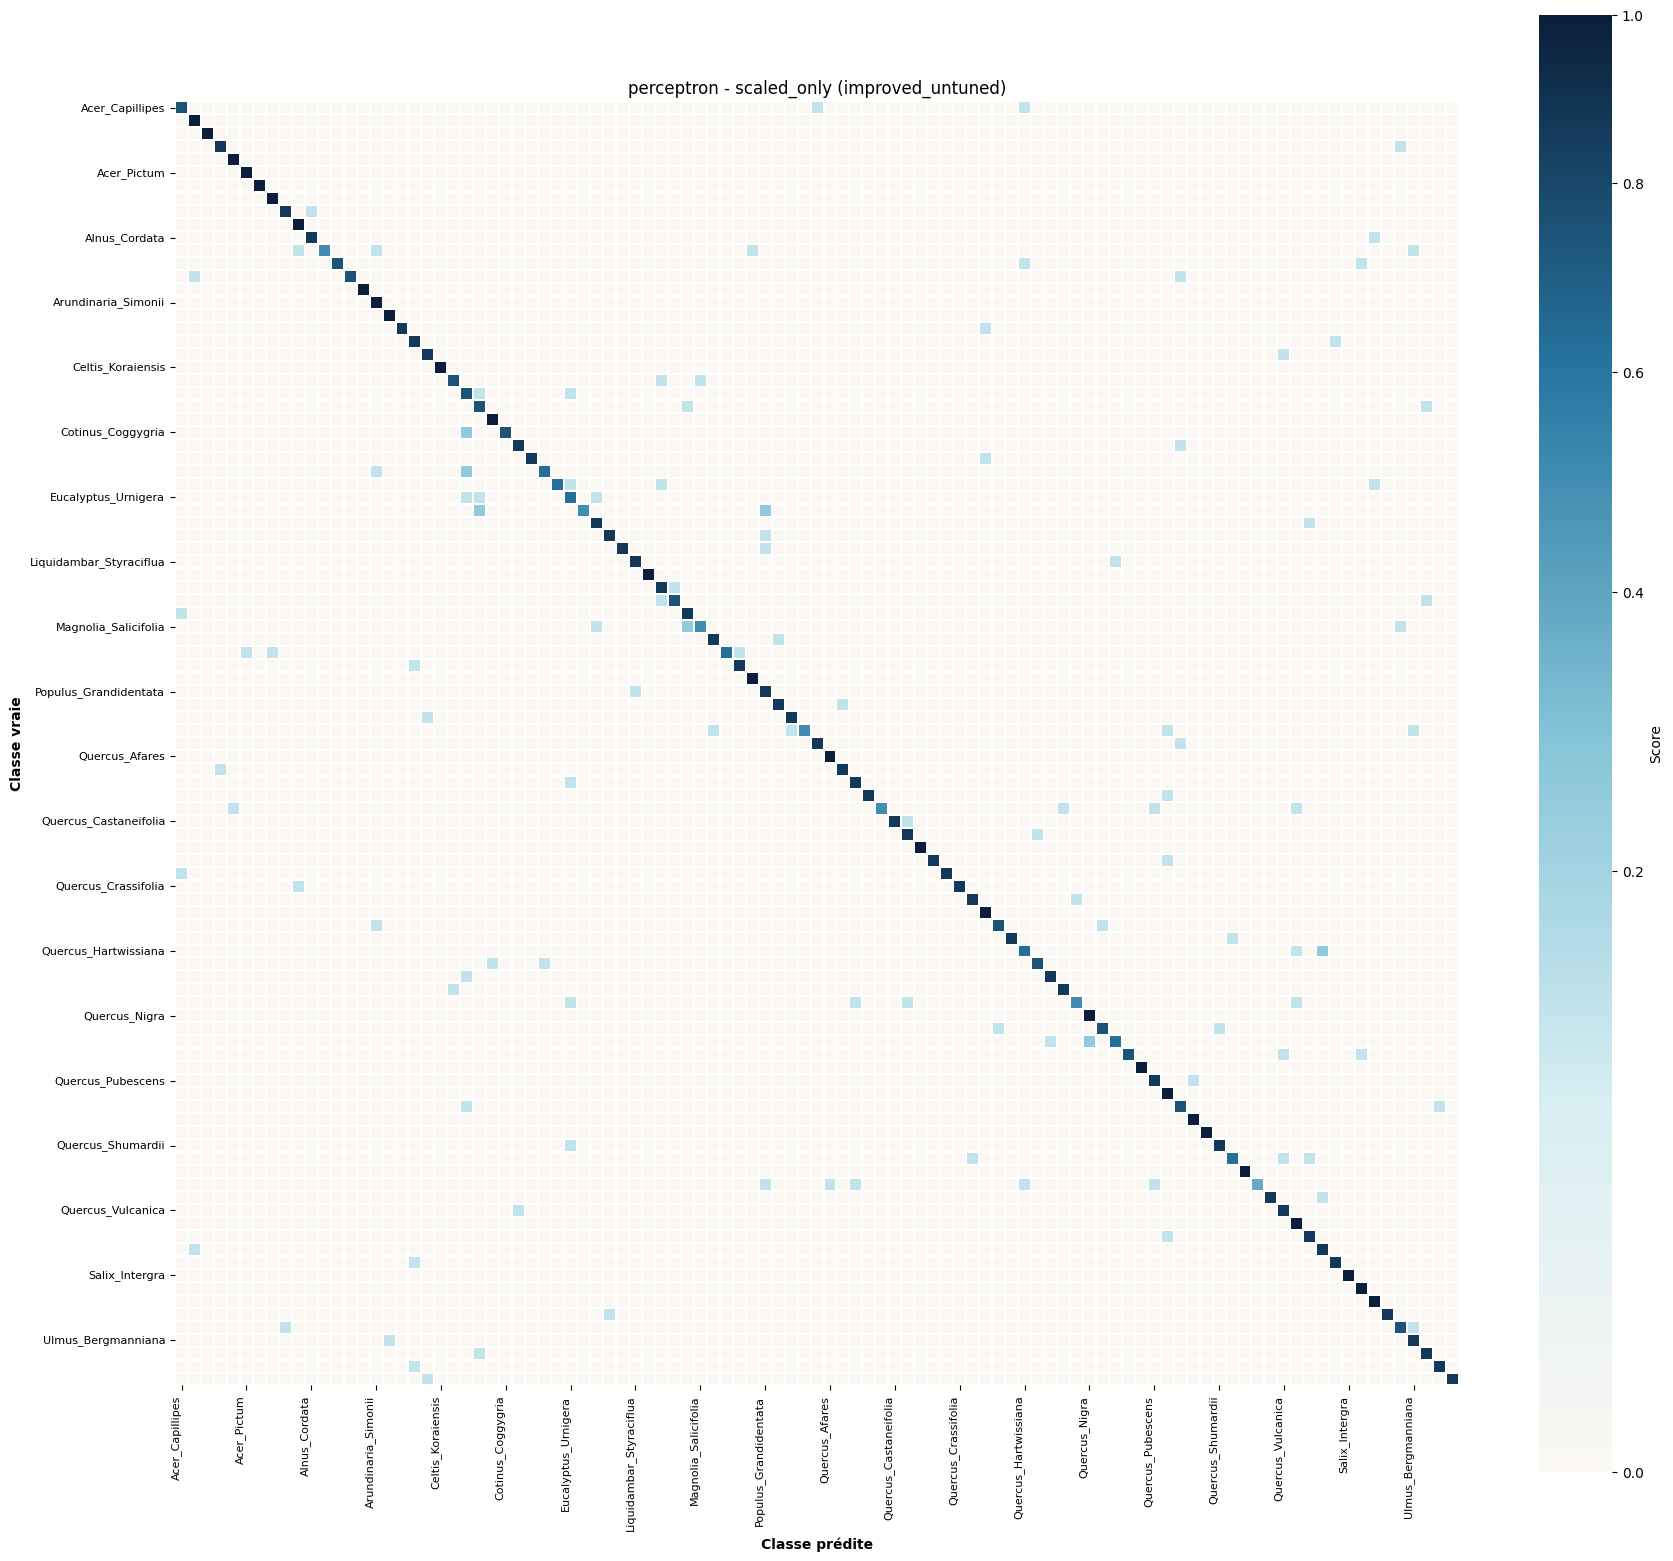

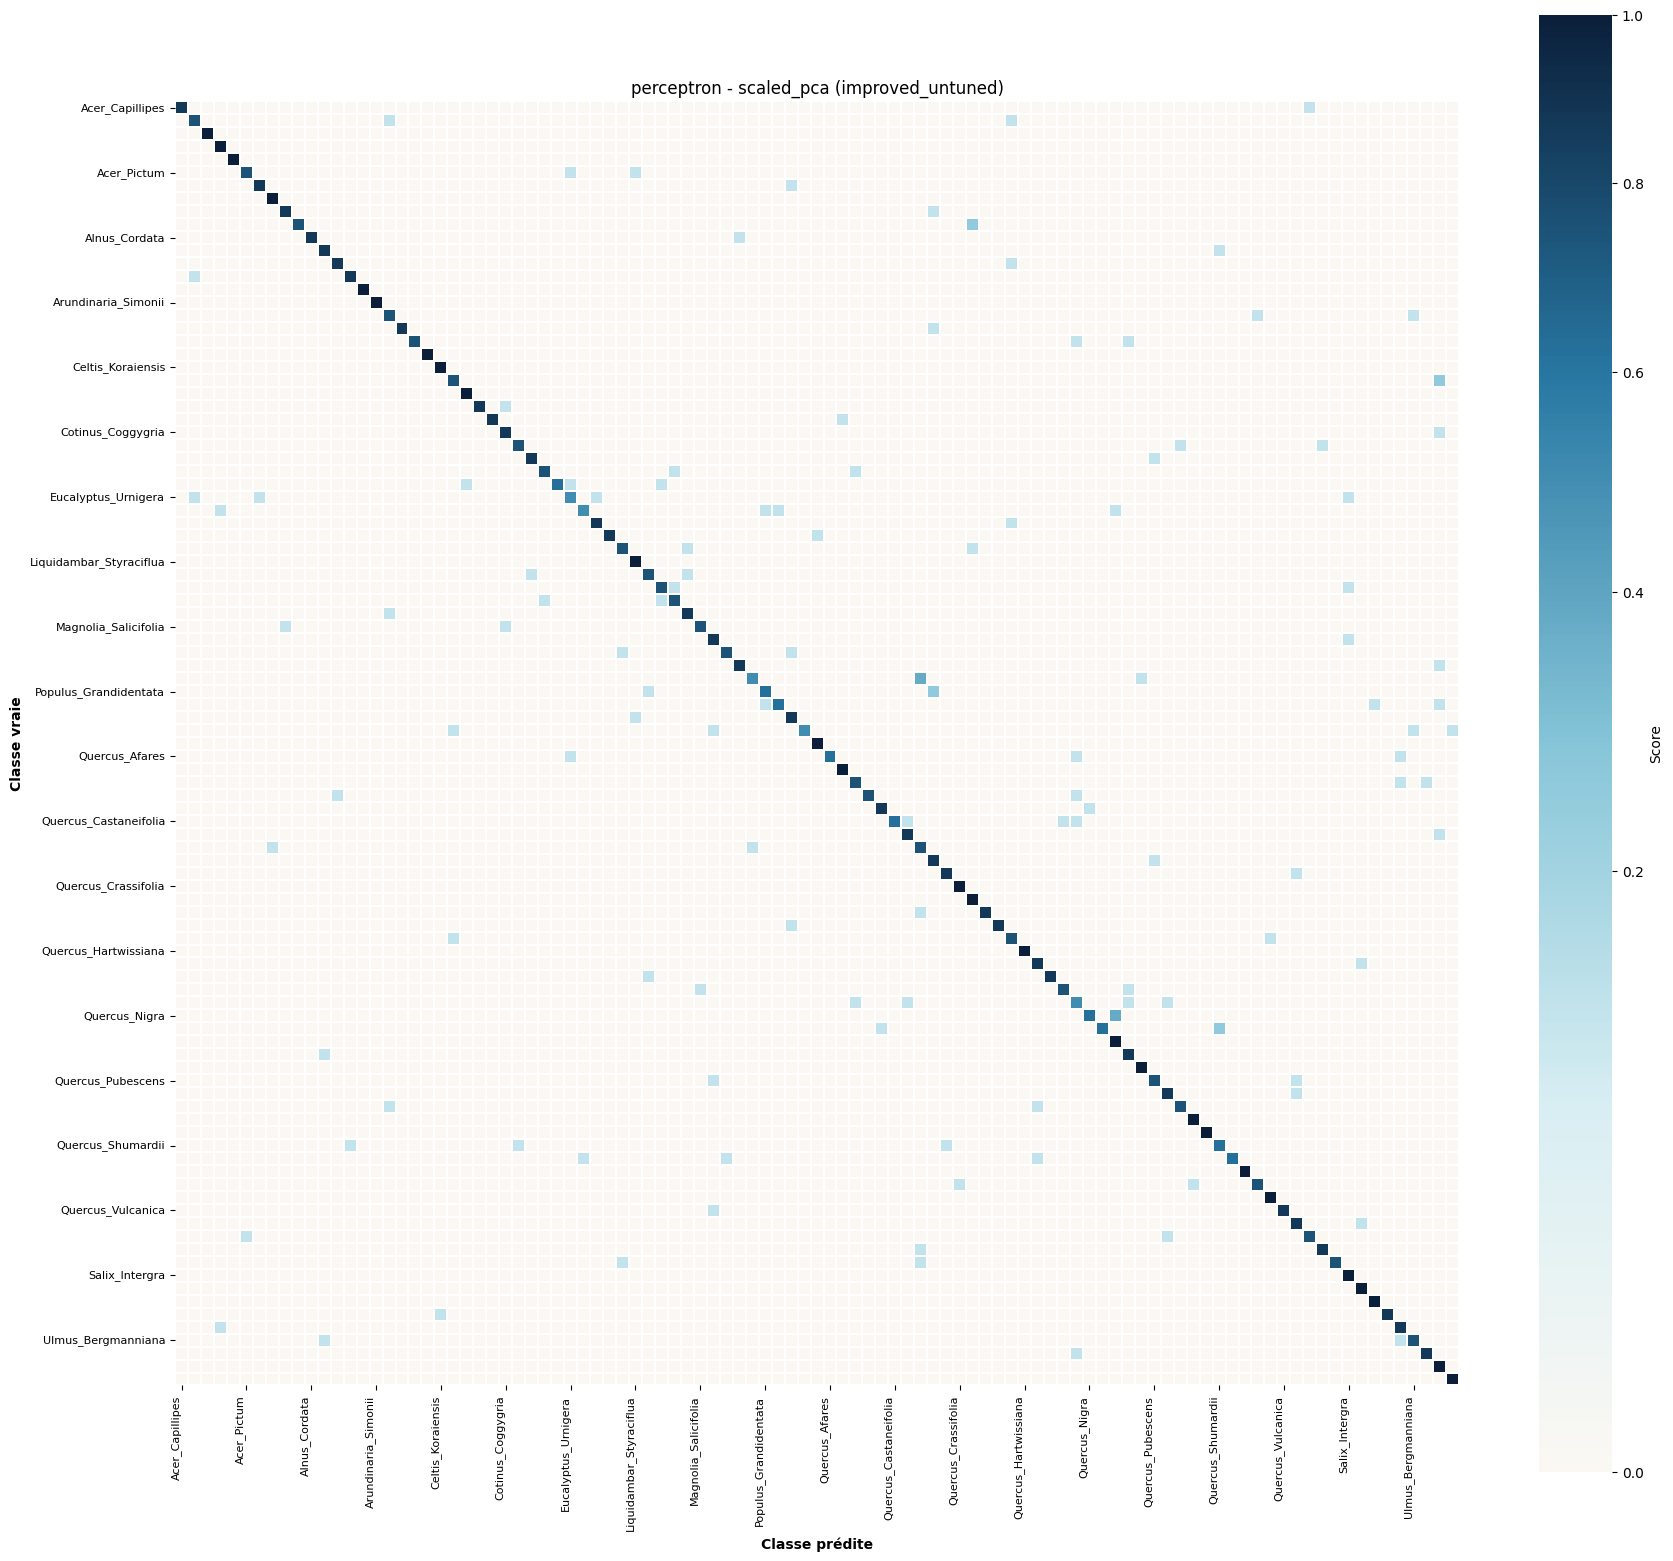

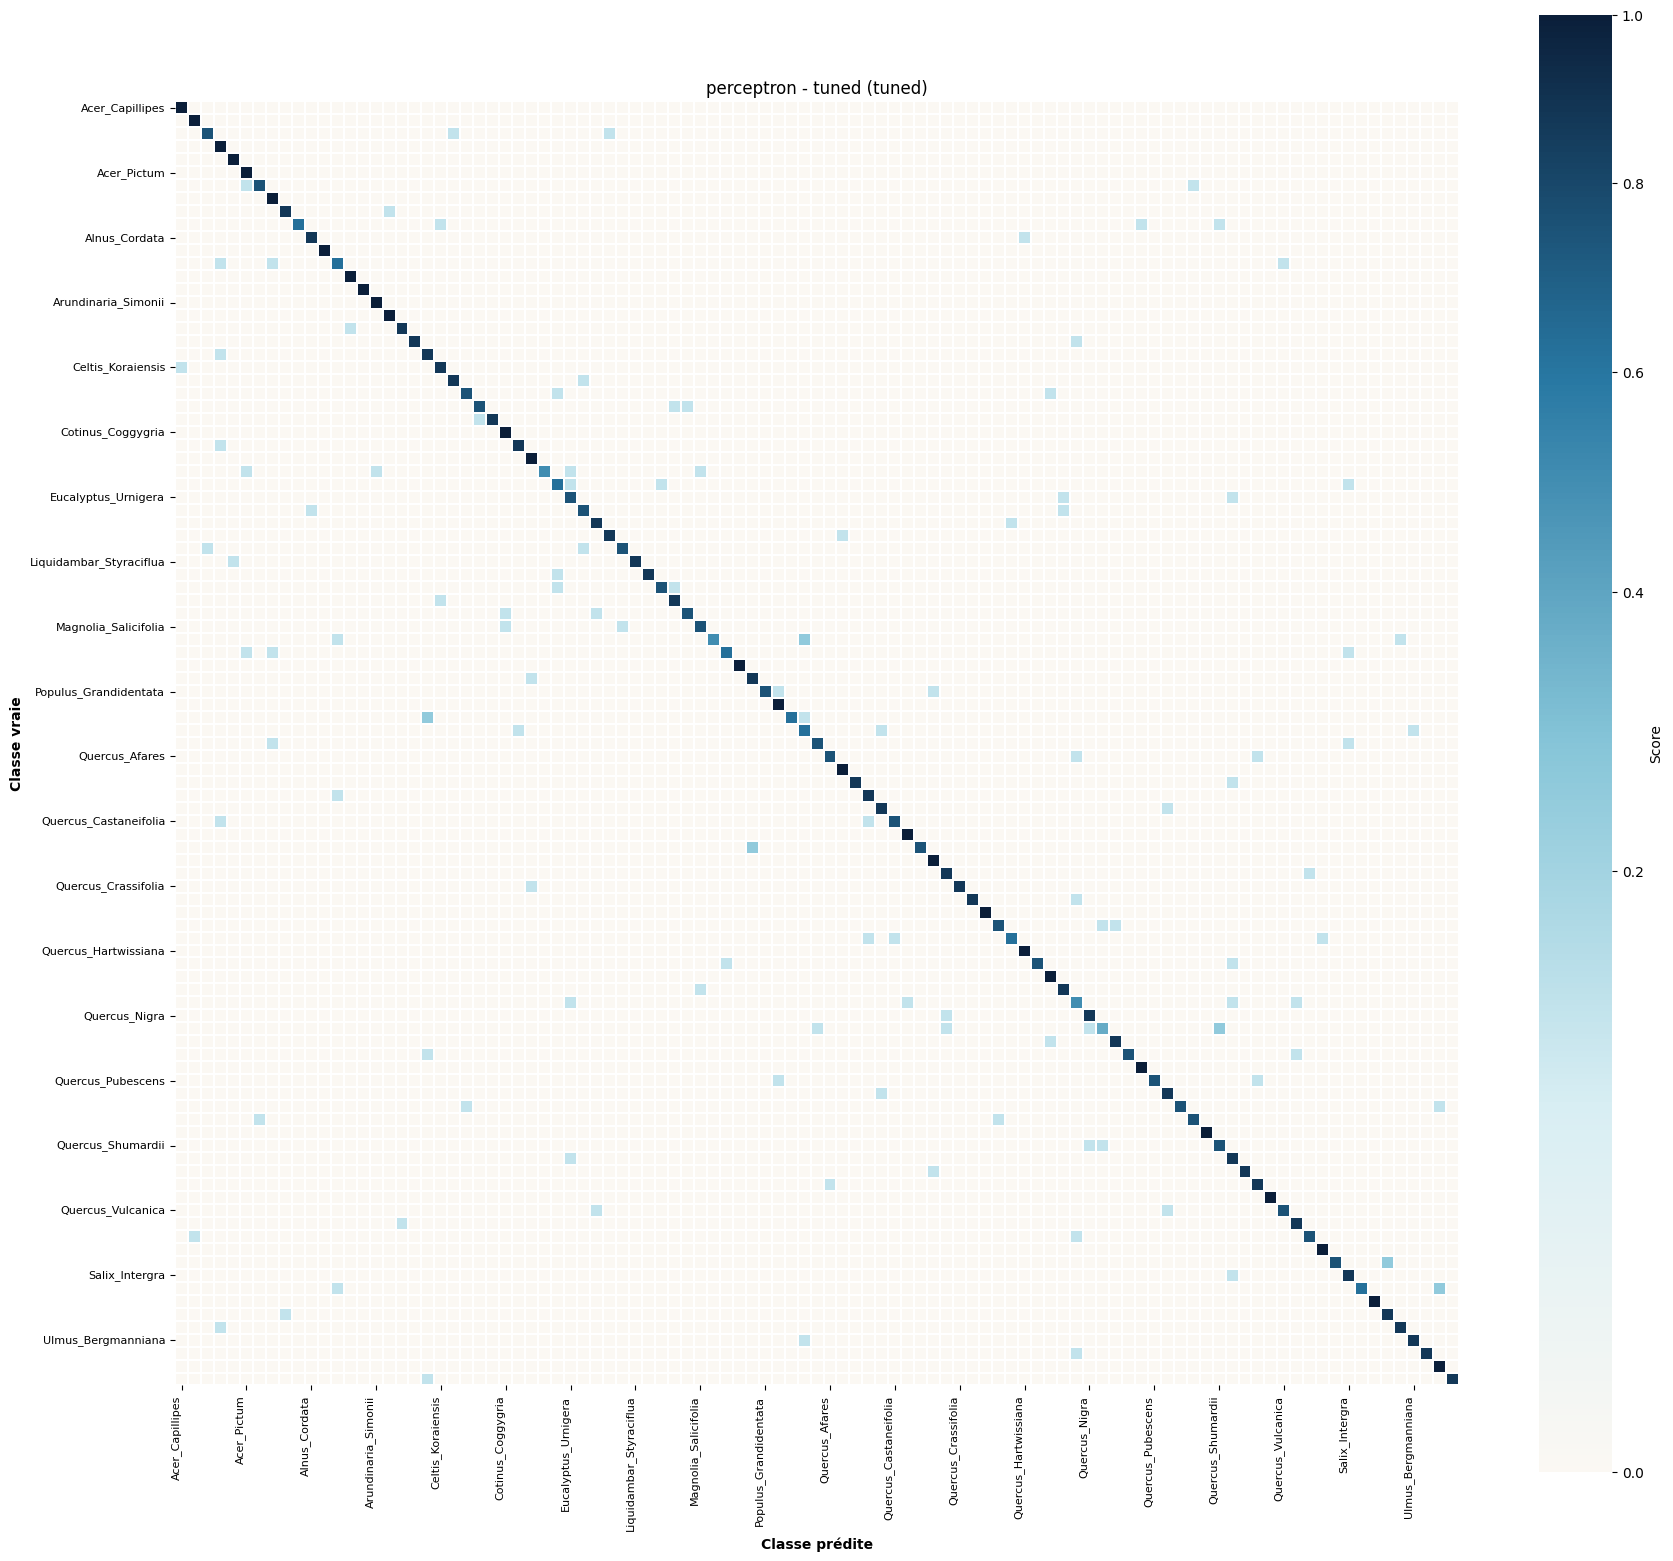

### regression_logistique

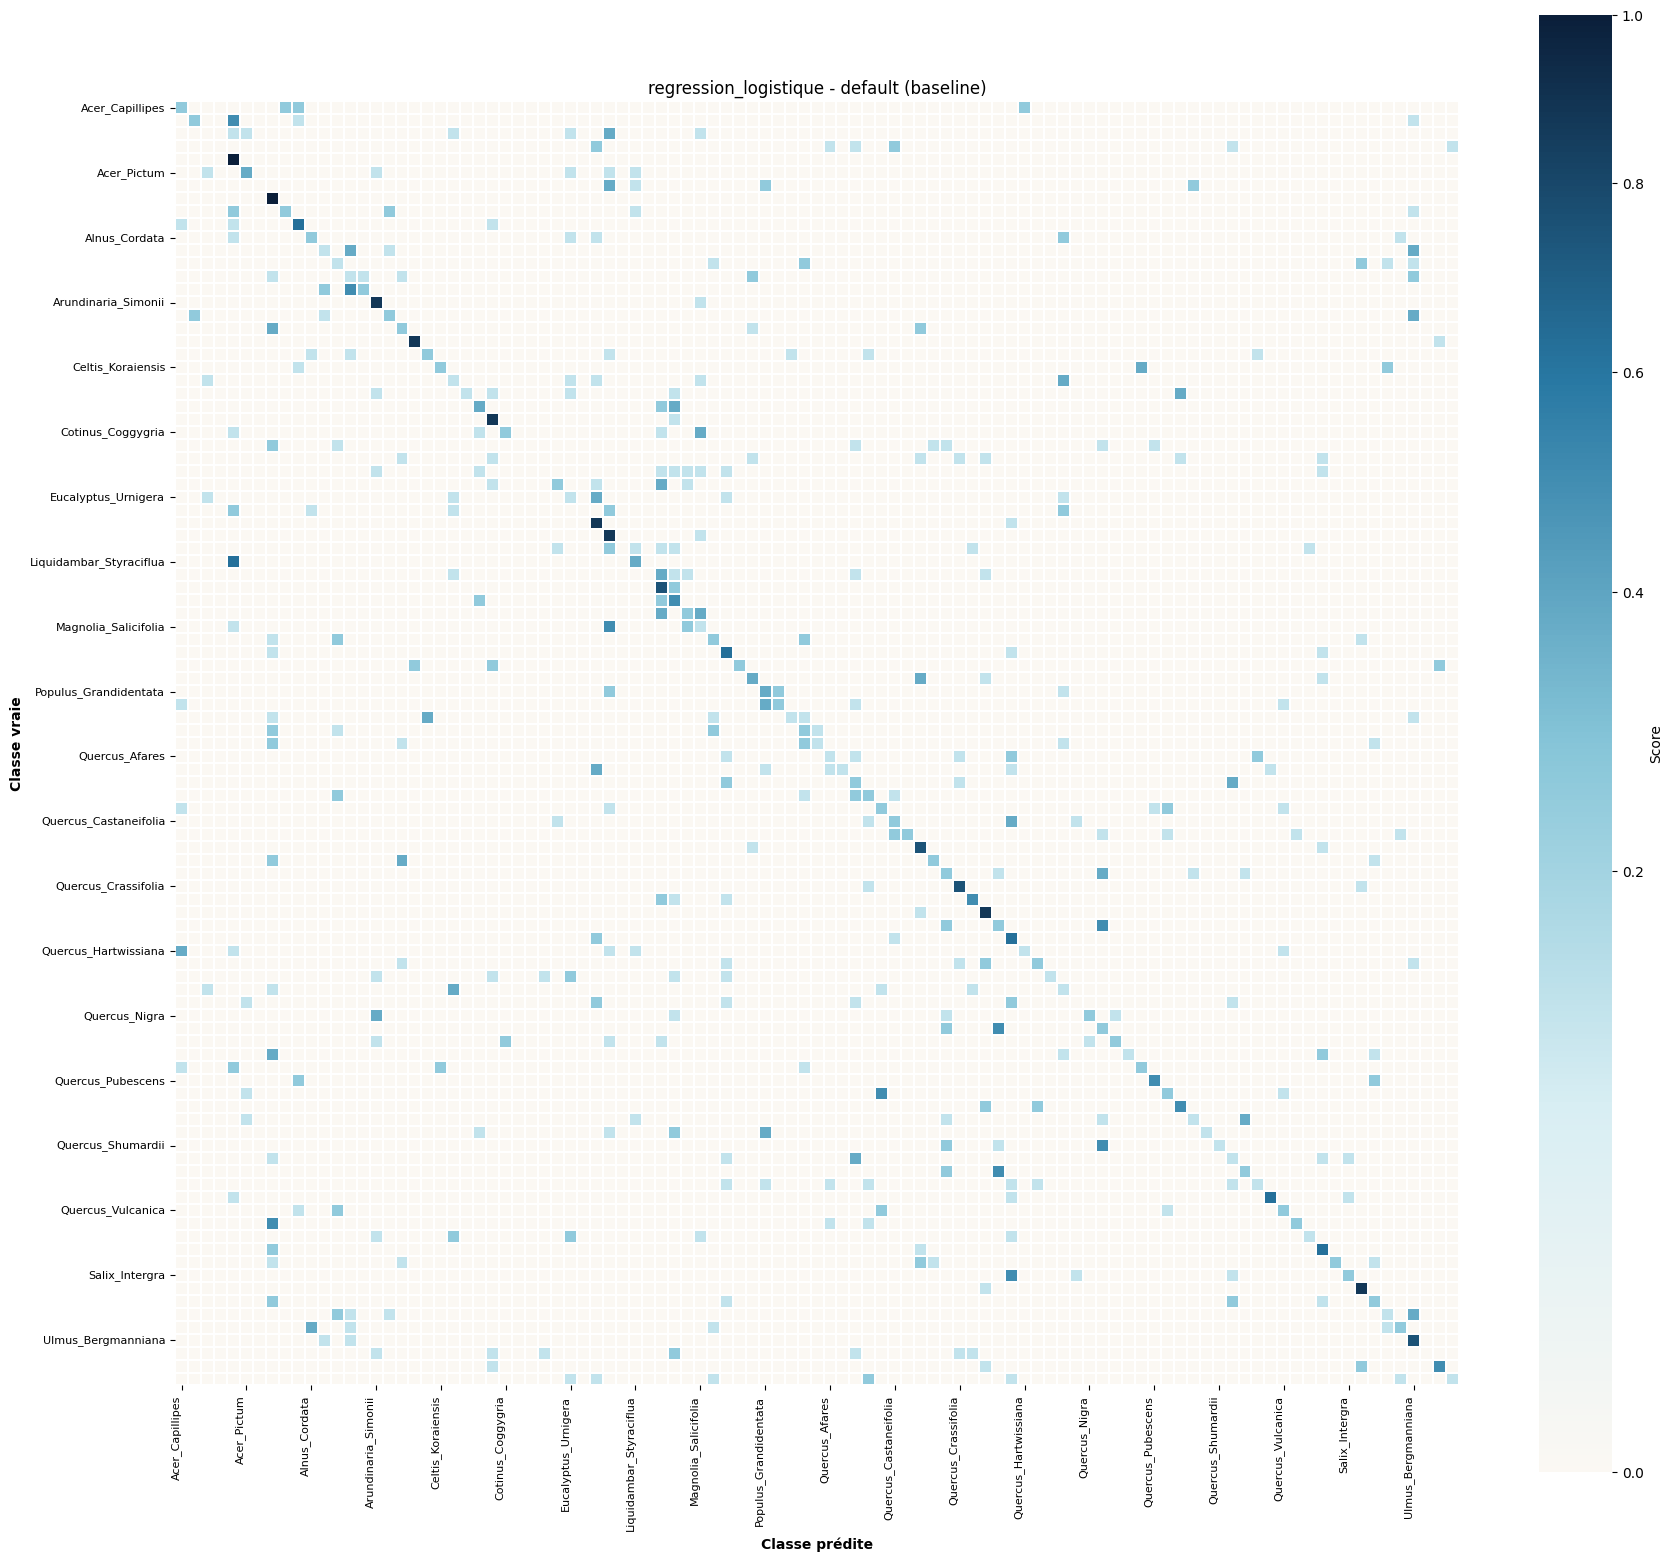

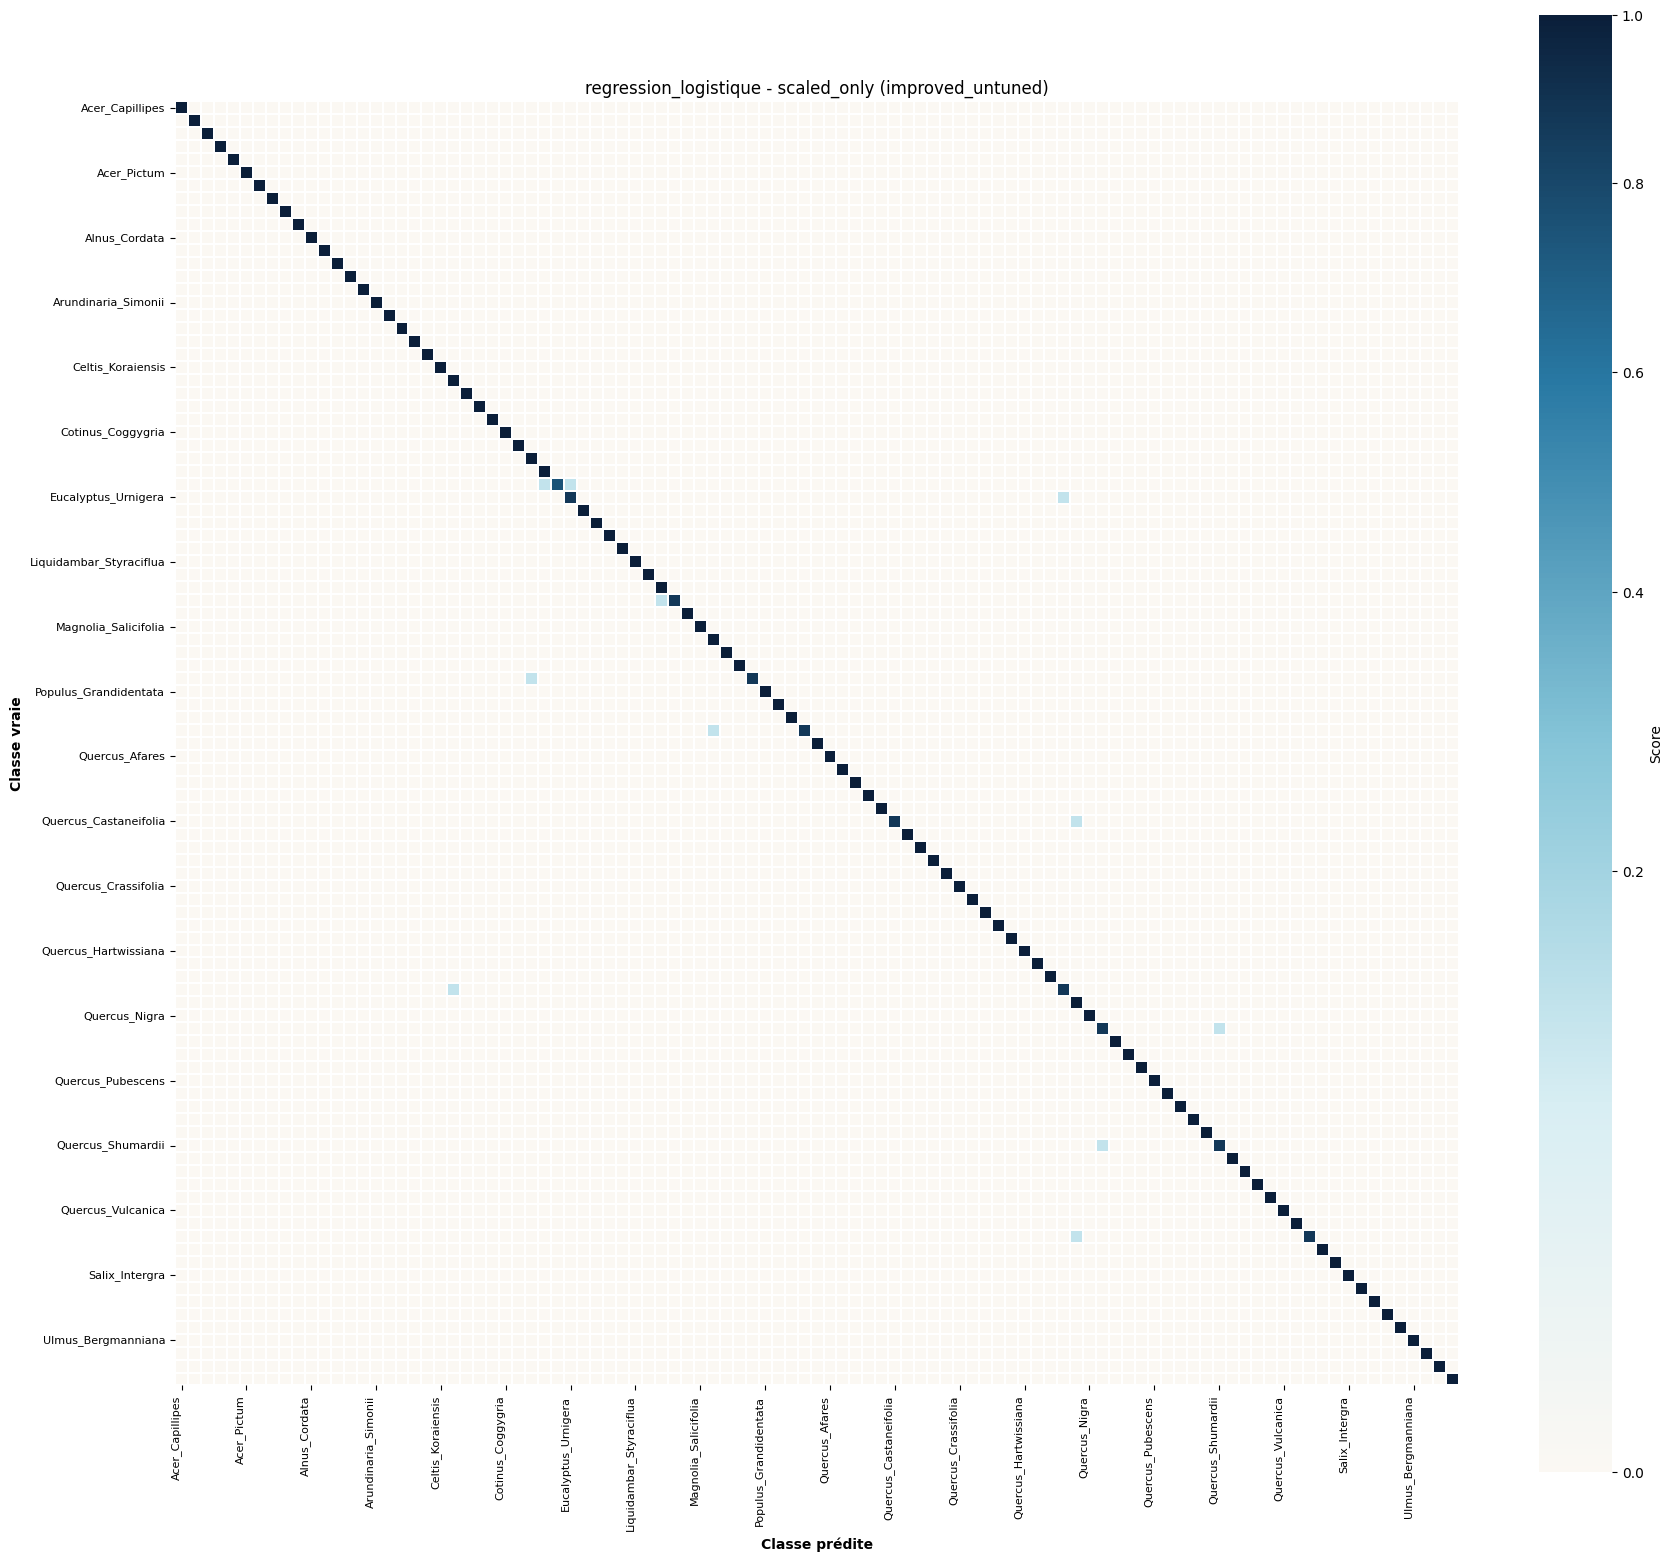

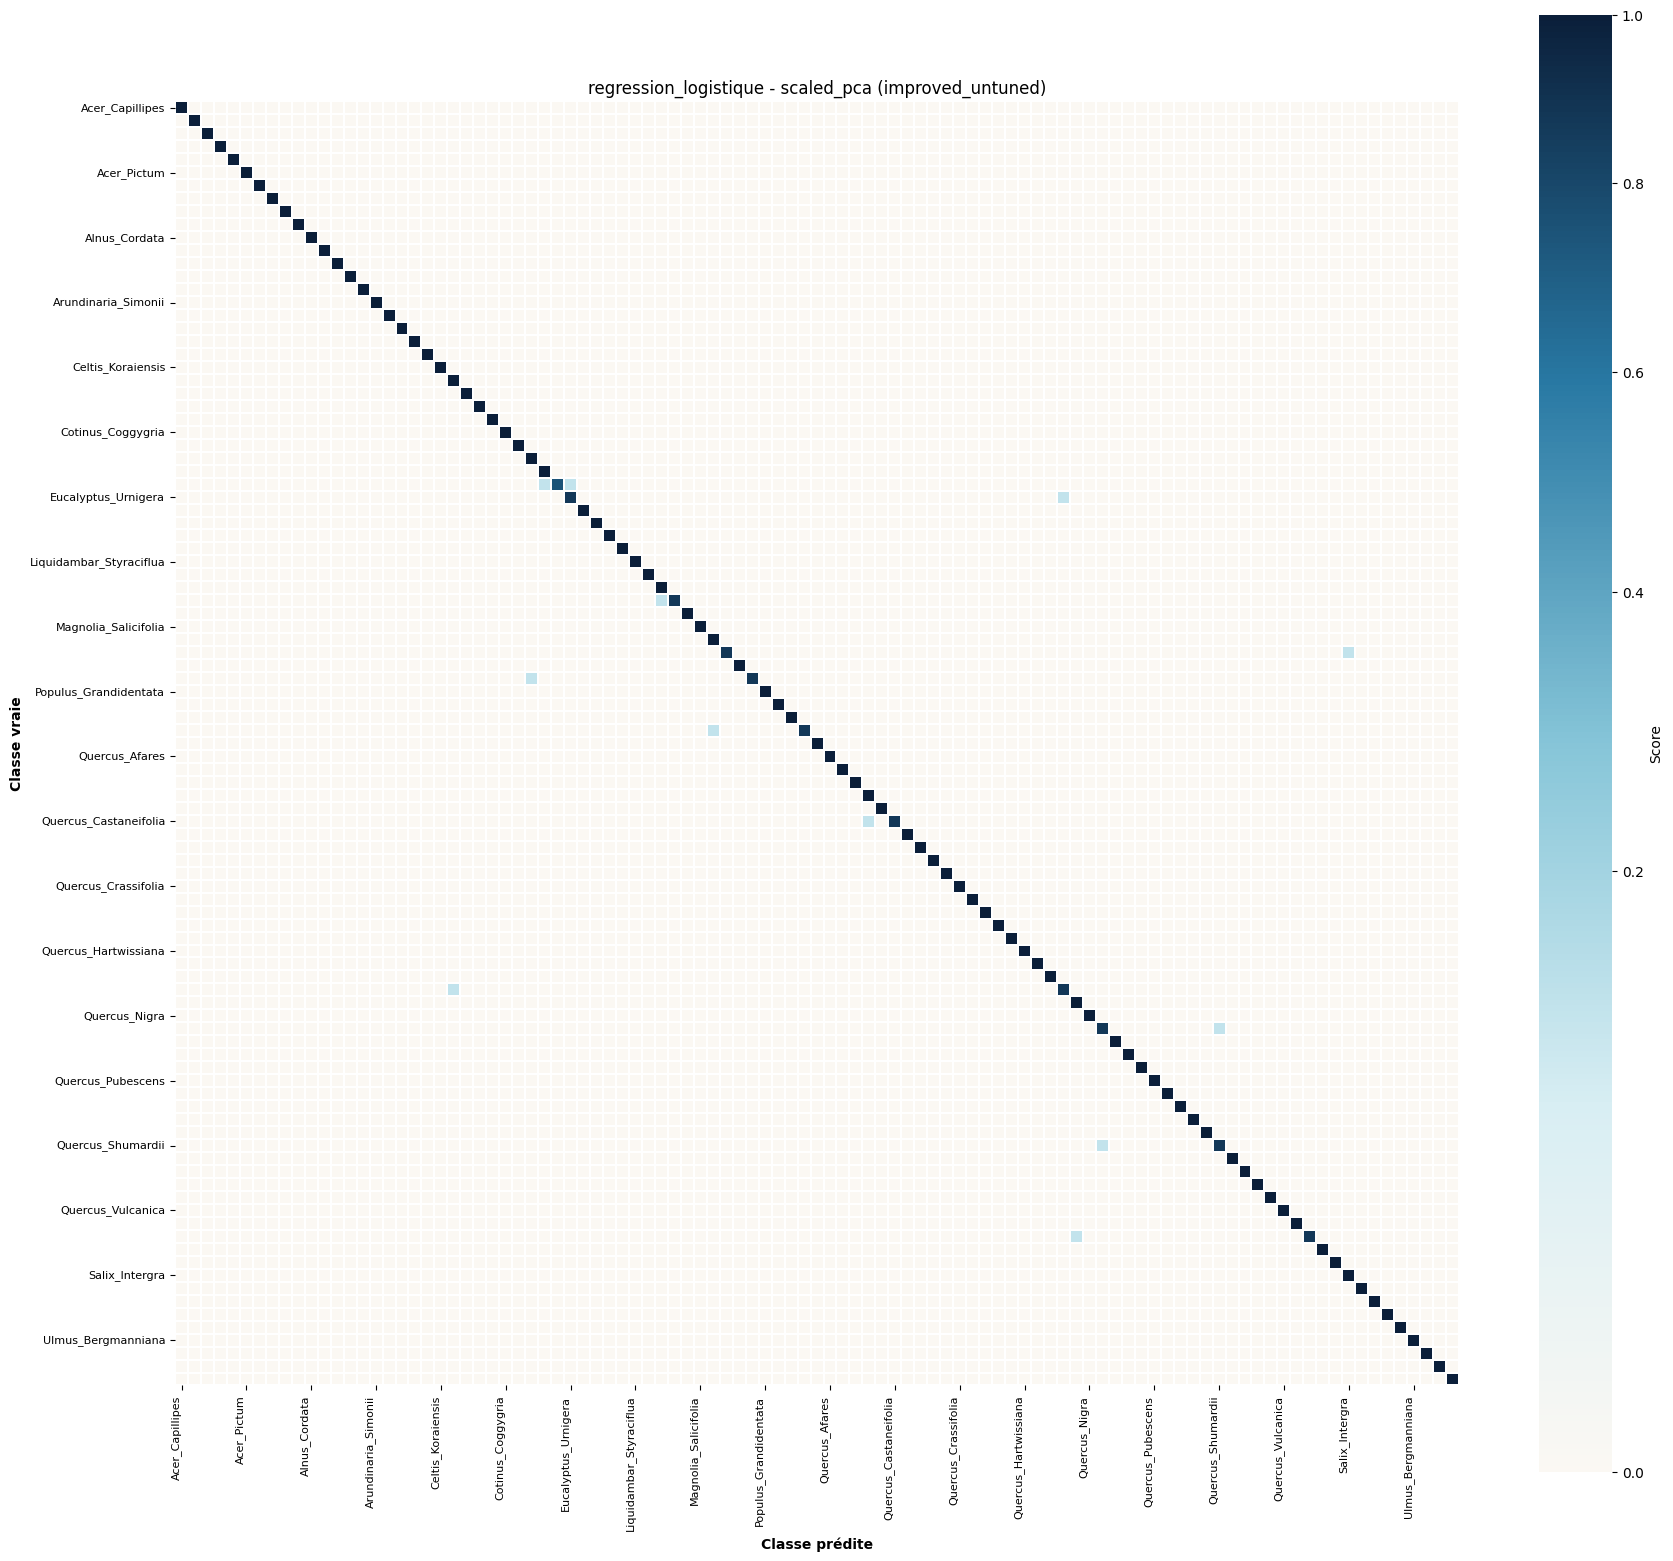

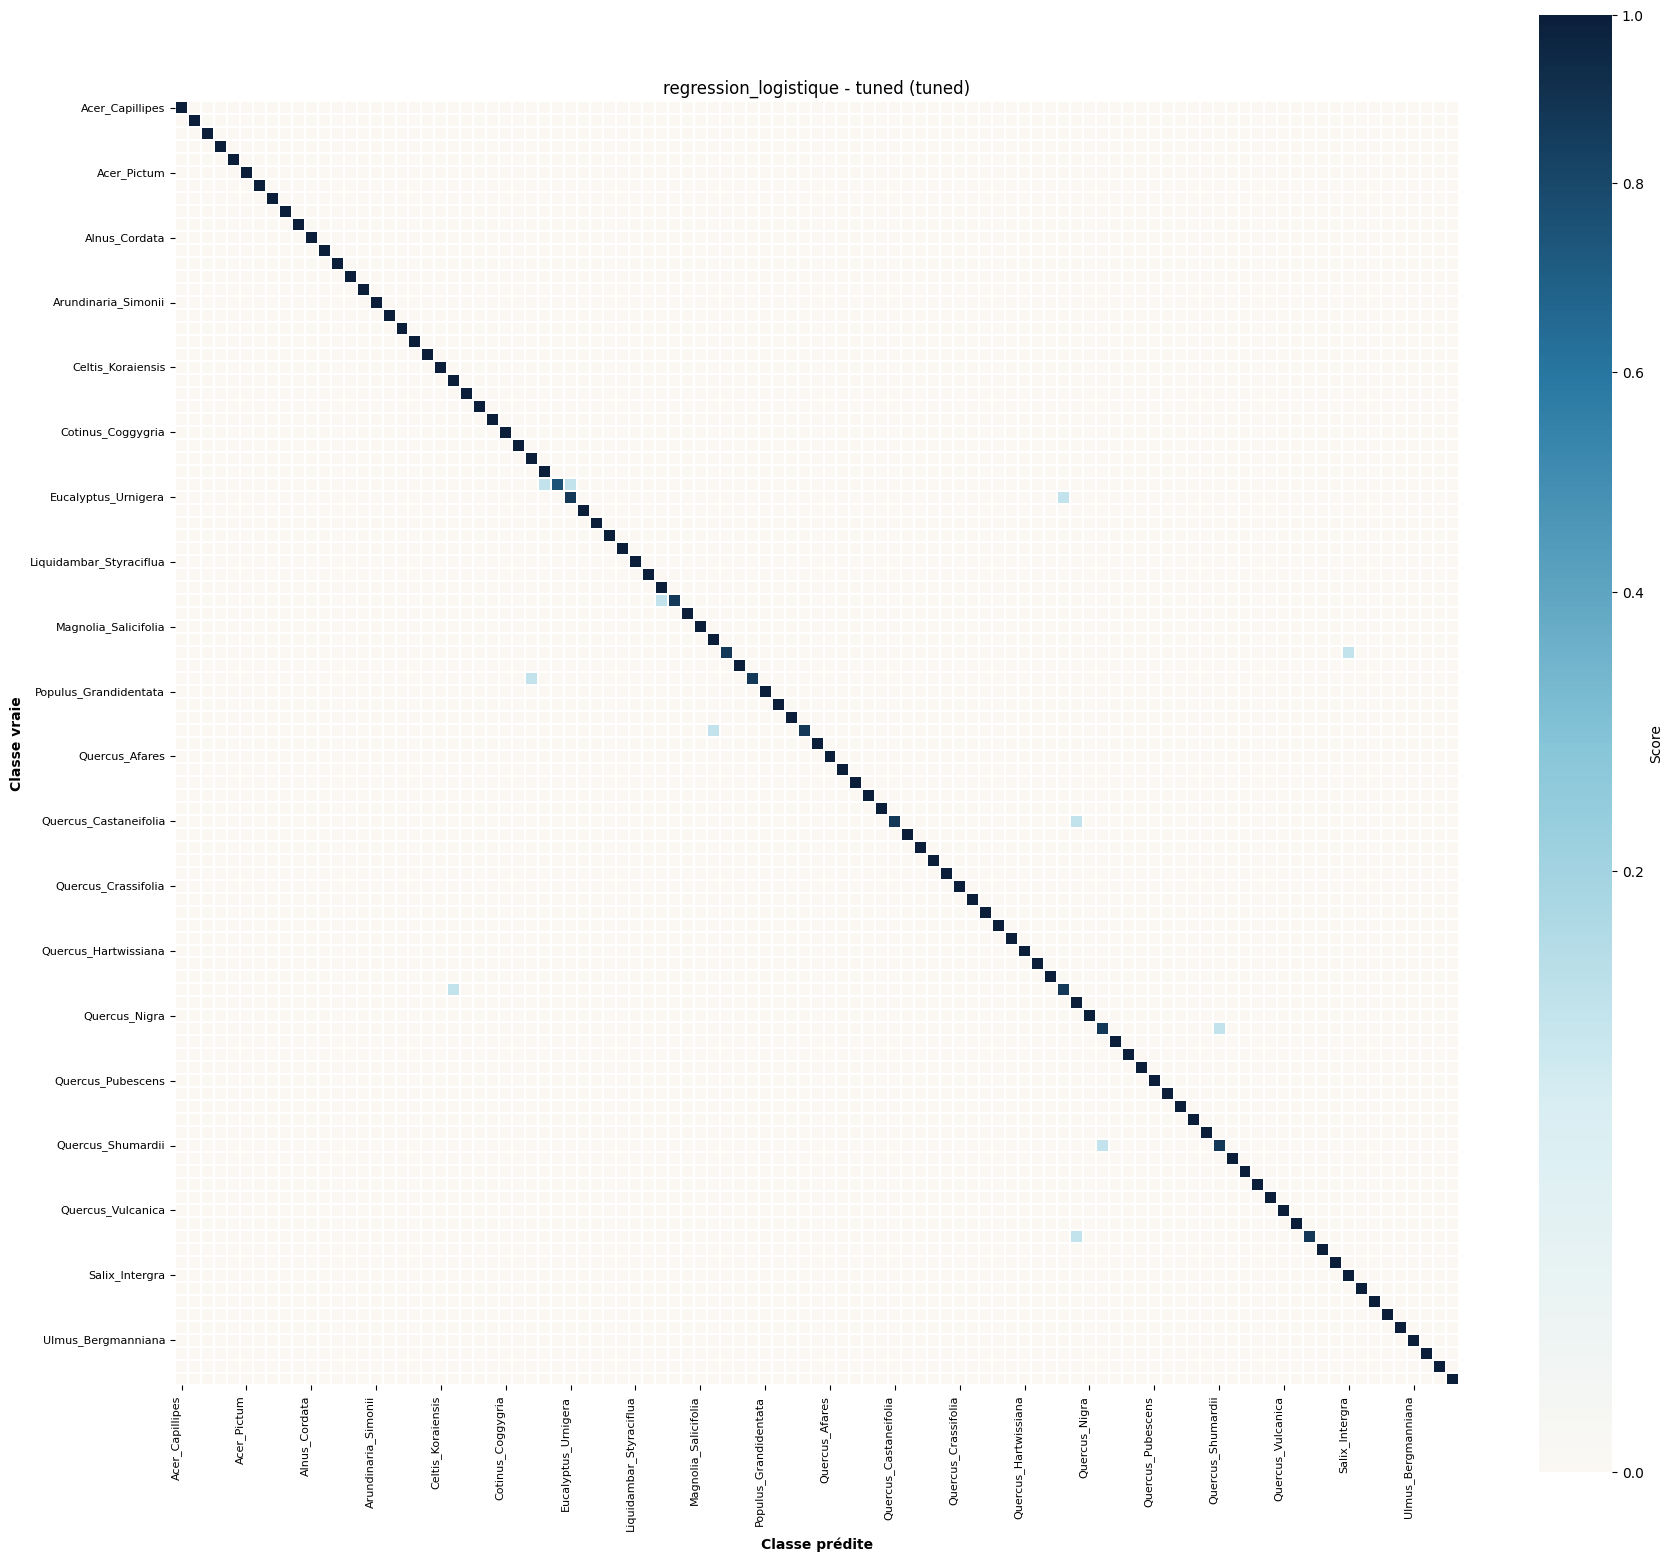

### svm

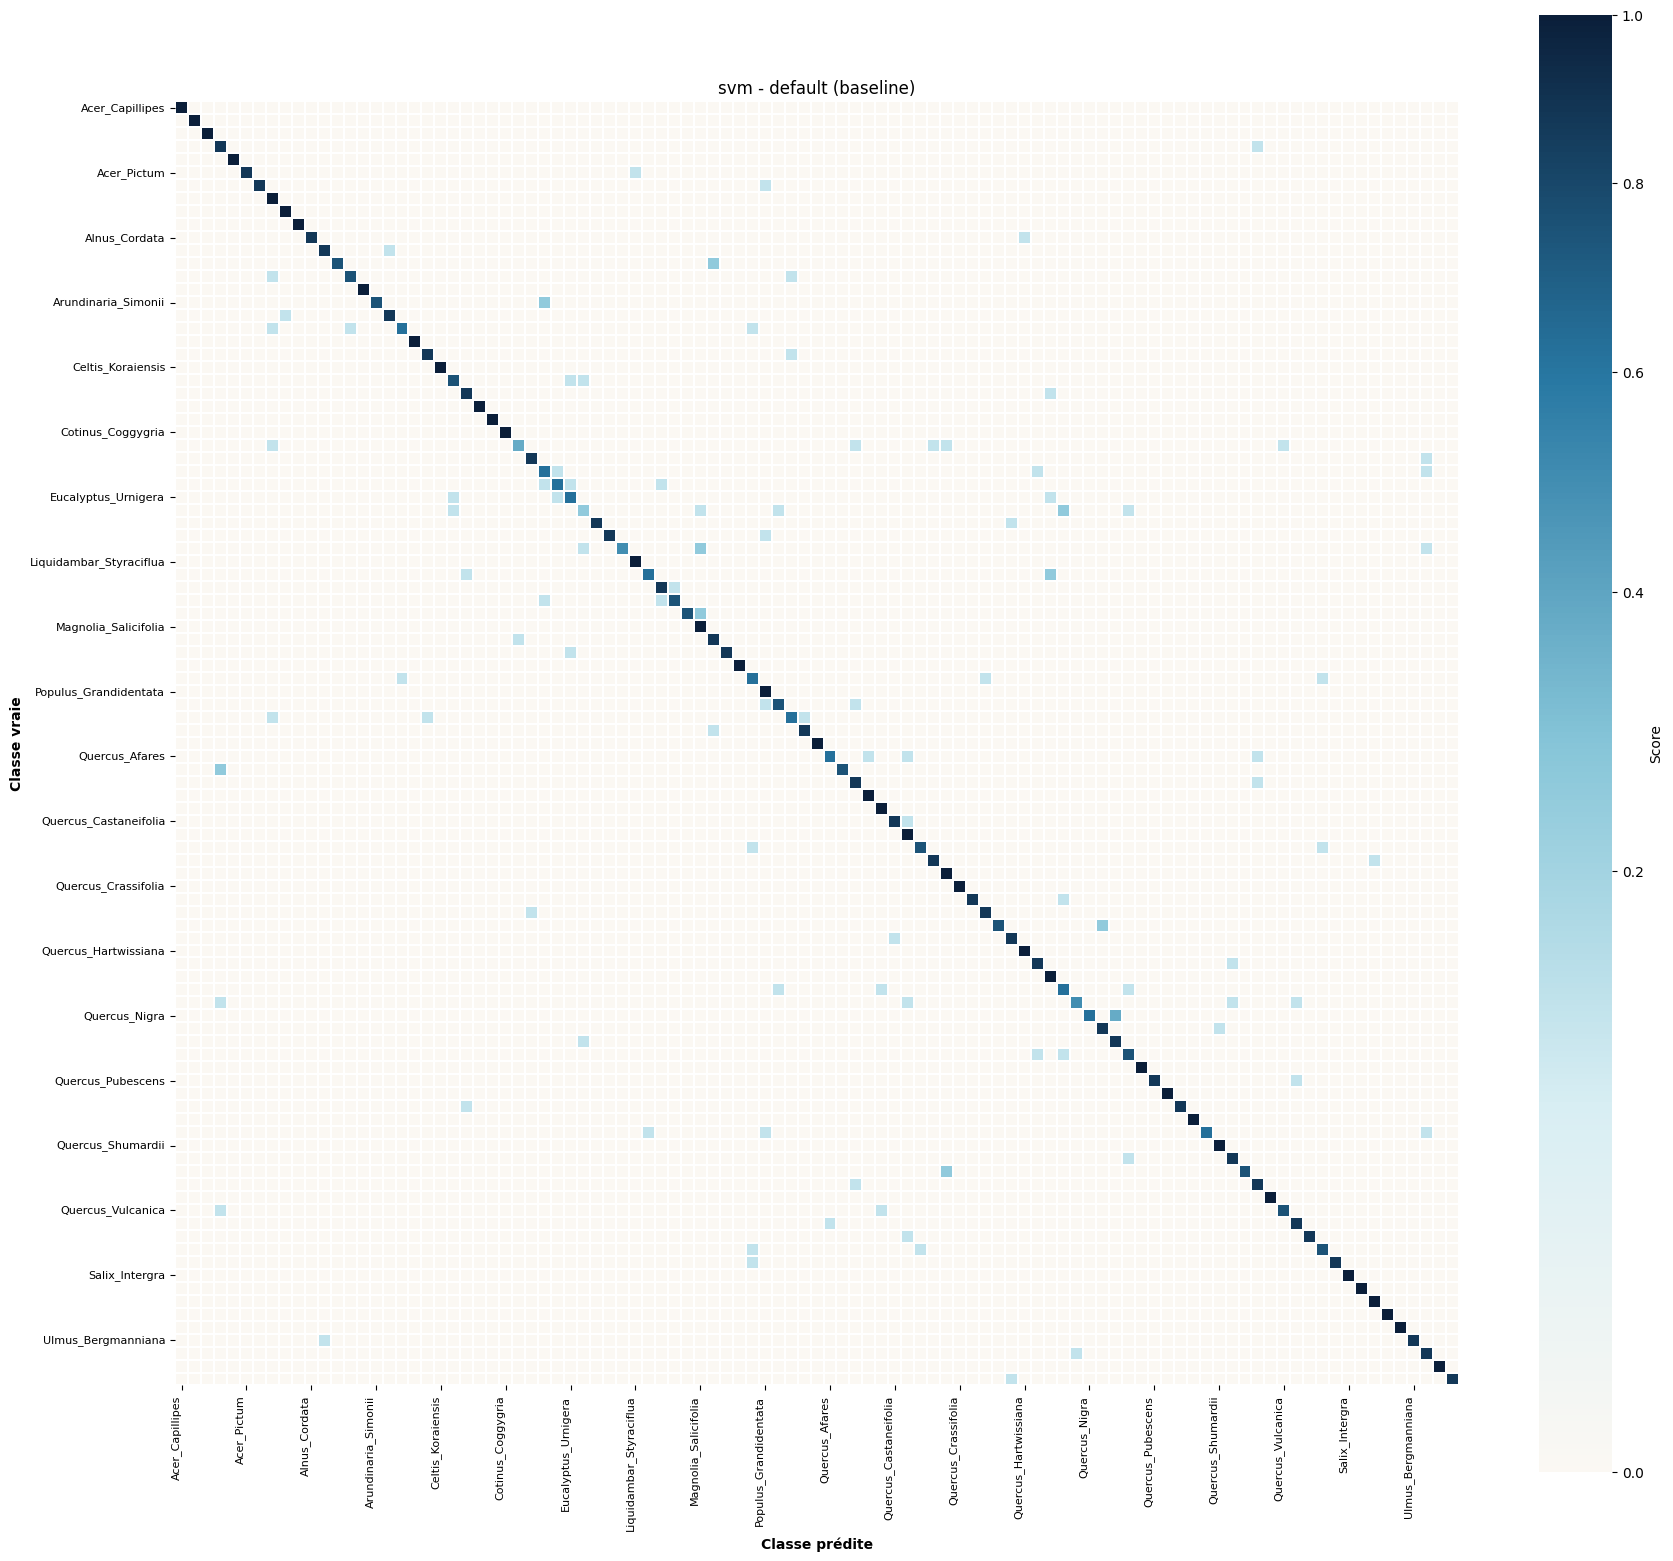

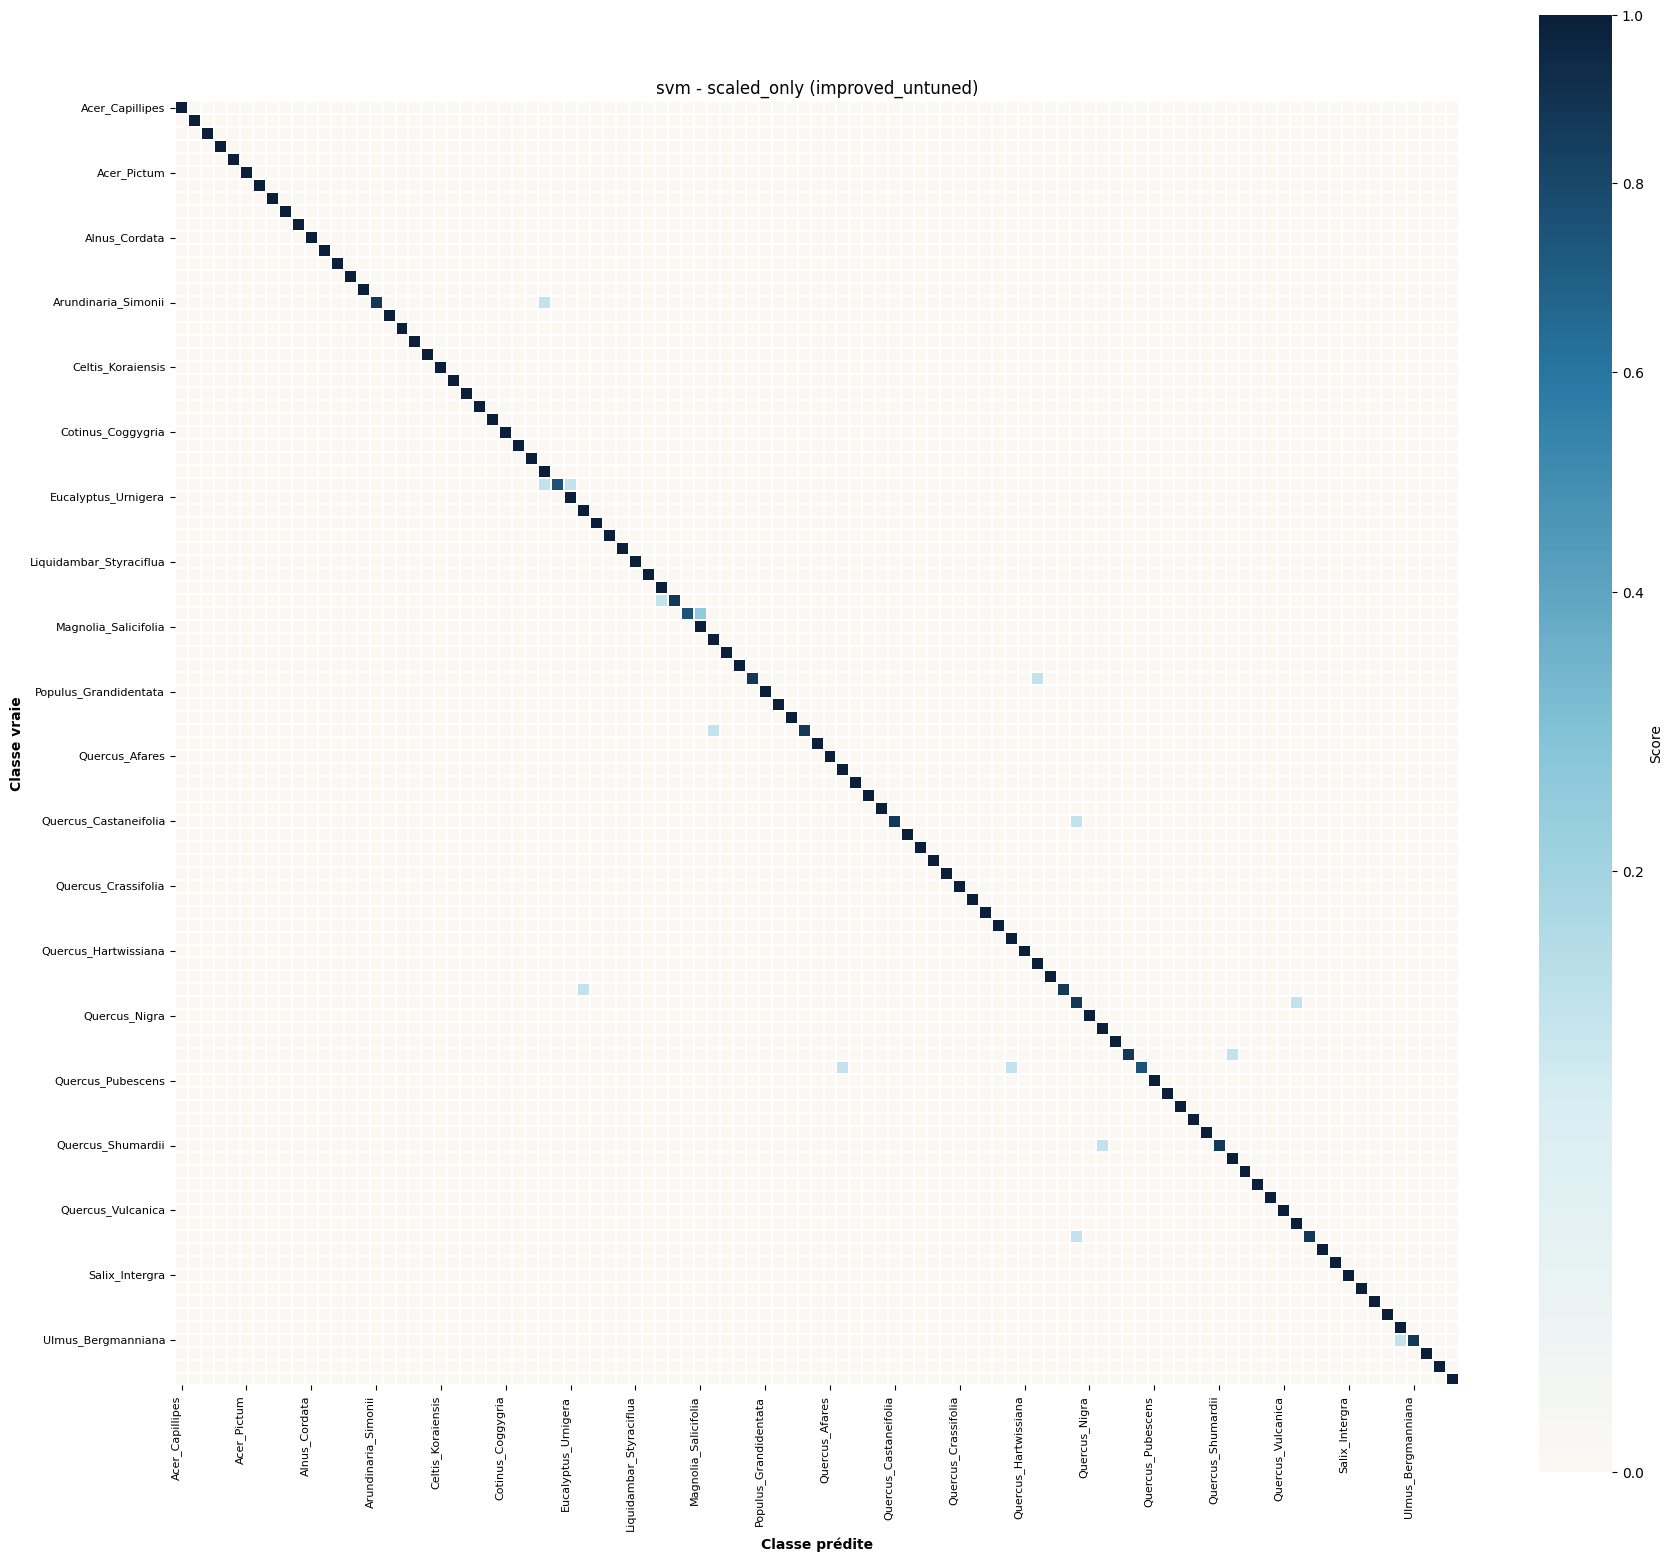

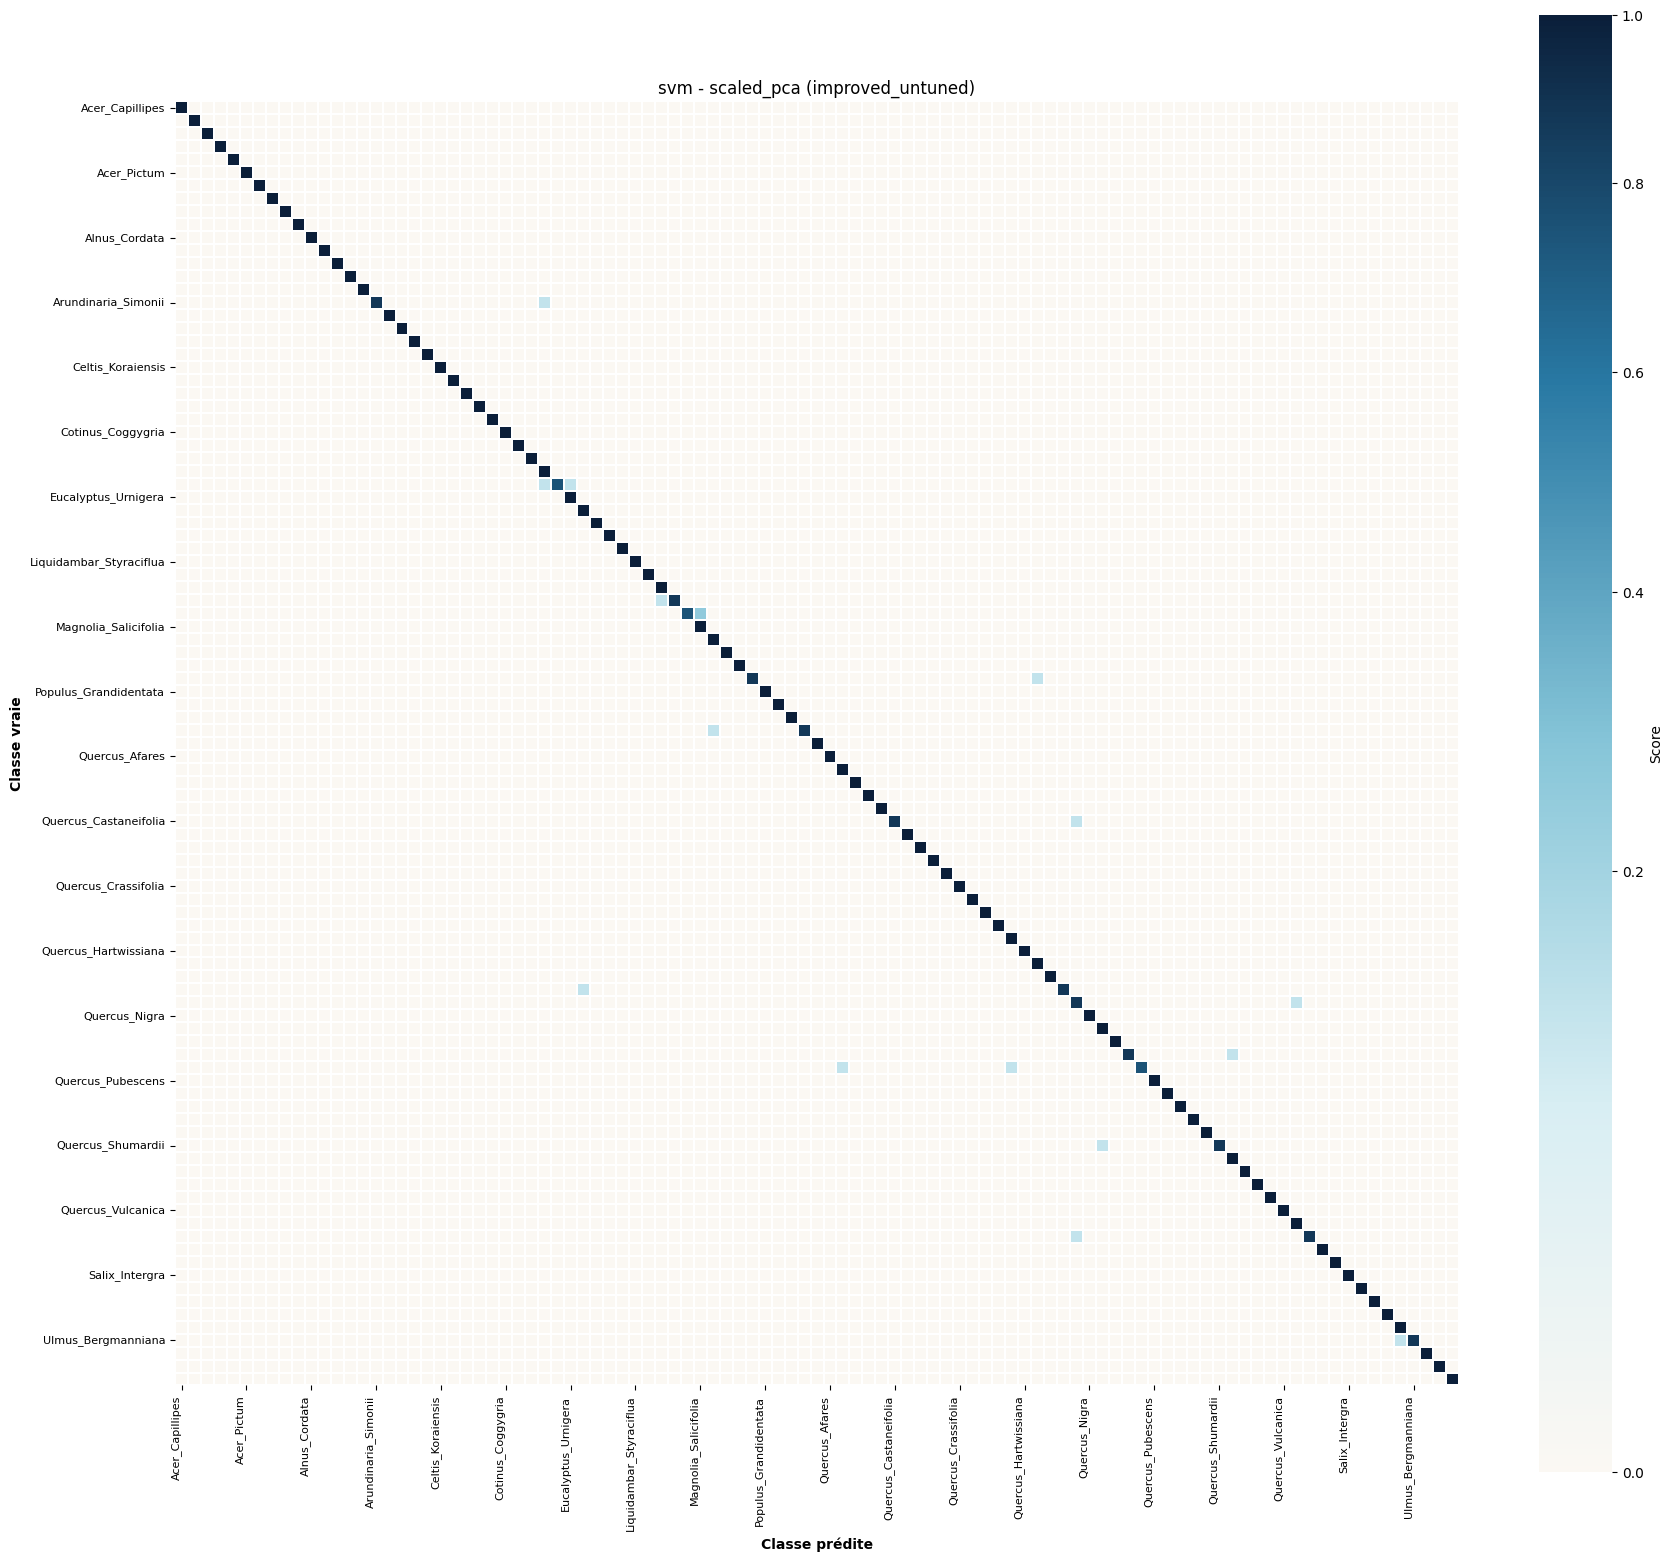

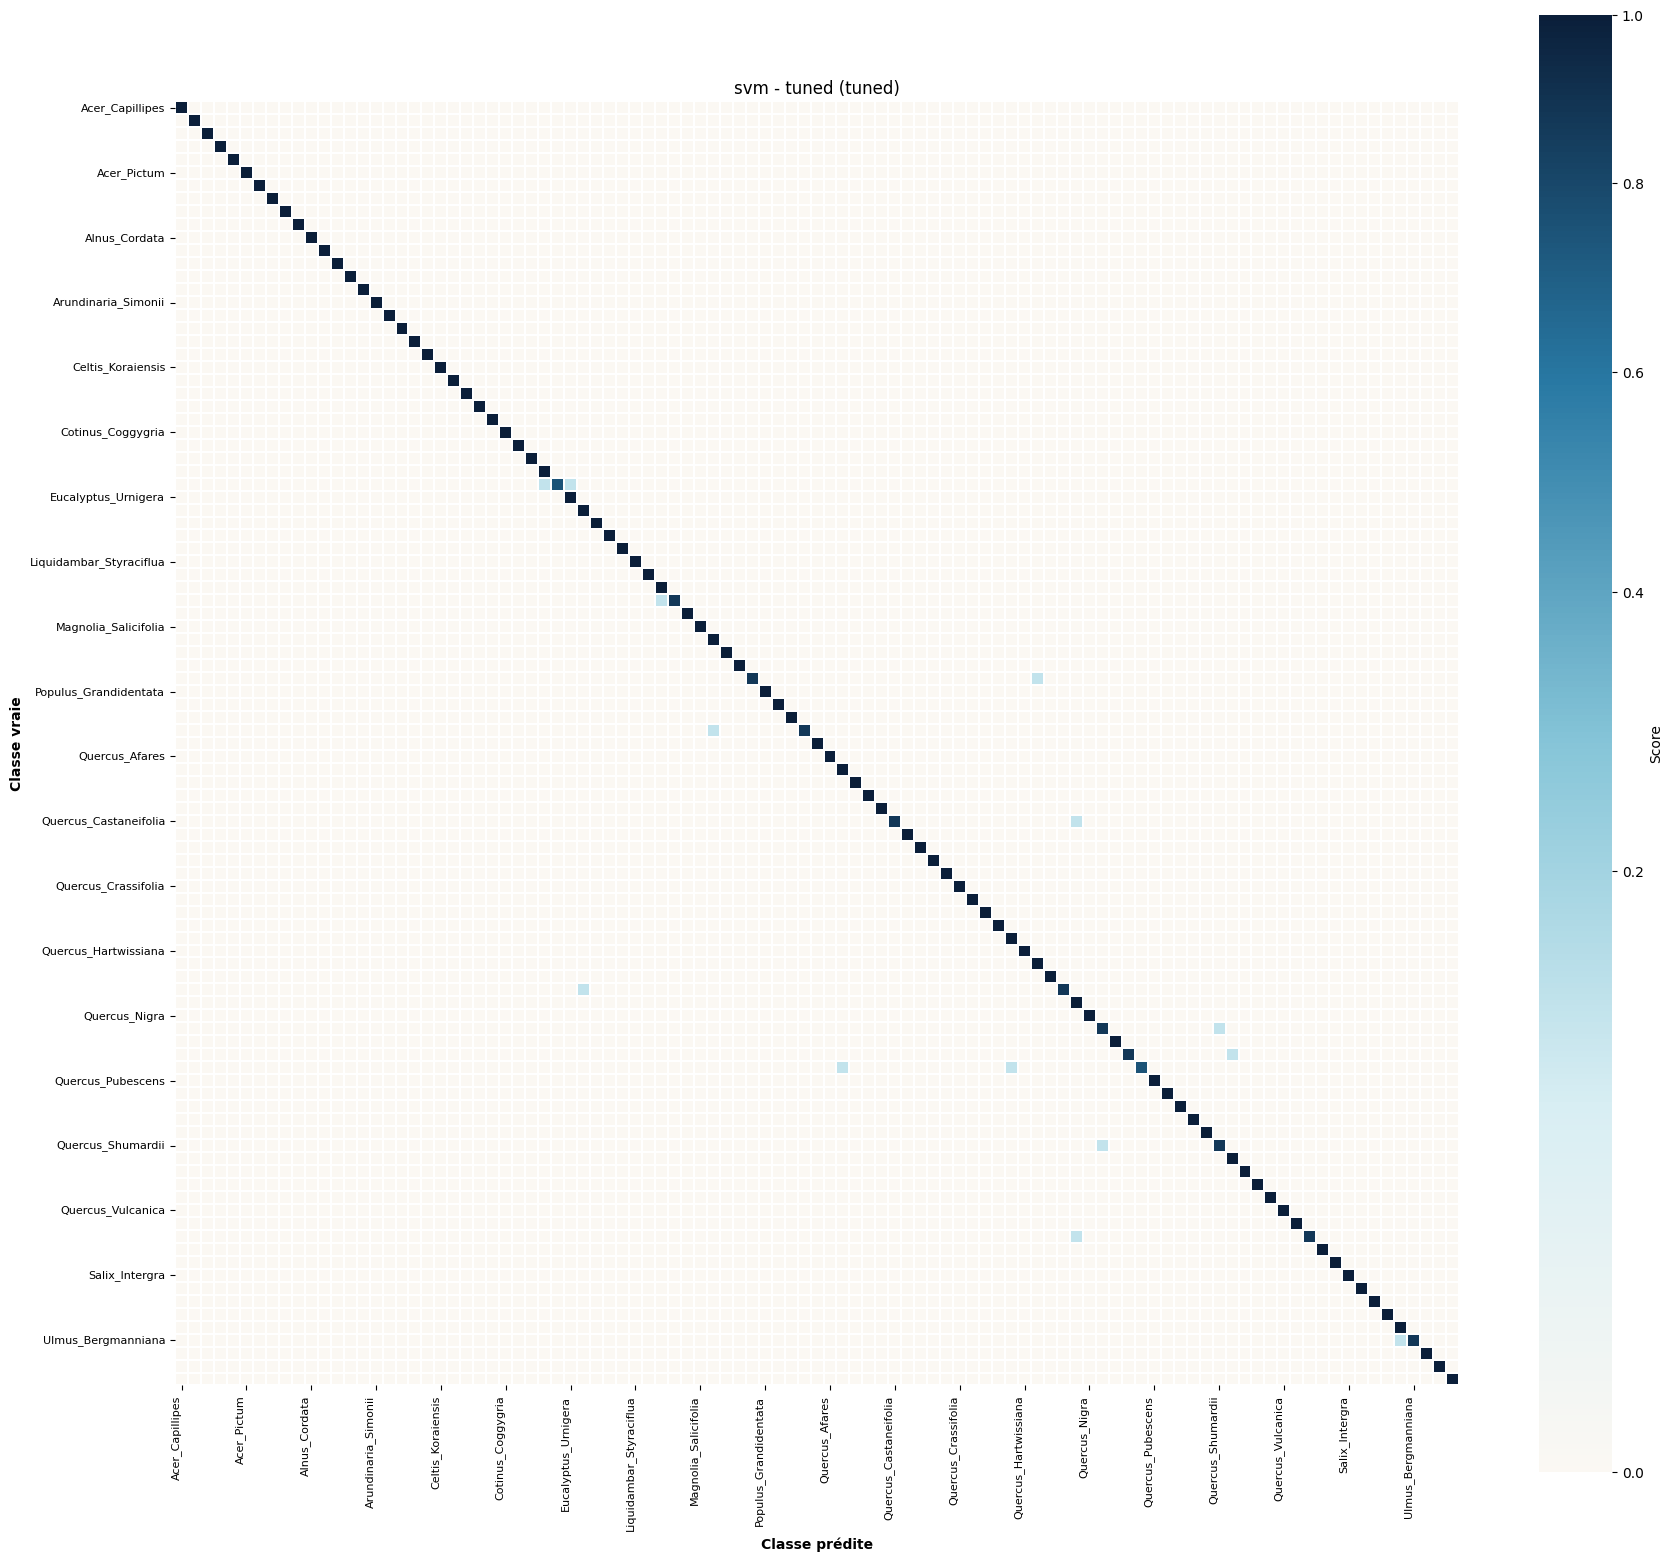

In [7]:
ordre_variantes = {
    "default": 0,
    "scaled_only": 1,
    "scaled_pca": 2,
    "restricted_depth": 3,
    "tuned": 99,
}

catalogue_variantes = (
    mesures[["modele", "variante", "evaluation_stage"]]
    .drop_duplicates()
    .assign(
        modele=lambda df: df["modele"].astype("string"),
        variante=lambda df: df["variante"].astype("string"),
        _ordre=lambda df: df["variante"].map(lambda v: ordre_variantes.get(str(v), 50)),
    )
    .sort_values(["modele", "_ordre", "variante"])
    .reset_index(drop=True)
)

predictions_cache = {}

for modele, sous_tableau in catalogue_variantes.groupby("modele"):
    nom_modele = str(modele)
    display(Markdown(f"### {nom_modele}"))
    for ligne in sous_tableau.to_dict("records"):
        variante = str(ligne["variante"])
        cle = (nom_modele, variante)
        if cle not in predictions_cache:
            predictions_cache[cle] = charger_ou_generer_predictions_variante(
                nom_modele,
                variante,
                X,
                y,
                label_encoder=label_encoder,
                root=OUTPUT_ROOT,
            )

        predictions_variante = predictions_cache[cle]
        matrice = matrice_confusion_normalisee(
            predictions_variante["y_true"].to_numpy(),
            predictions_variante["y_pred"].to_numpy(),
                label_encoder=label_encoder,
            )
        ax = tracer_matrice_confusion(
            matrice,
            titre=f"{nom_modele} - {variante} ({ligne['evaluation_stage']})",
            annot=False,
            intervalle_ticks=5,
        )
        plt.show()


### Complementarite potentielle des erreurs

Le tableau suivant compare les meilleurs candidats `tuned` en termes de desaccord et de recouvrement des erreurs.
Il sert a preparer une hypothese d'ensemble sans conclure qu'une combinaison est deja justifiee.


In [8]:
predictions_top = {modele: charger_predictions_modele(modele, "tuned", root=OUTPUT_ROOT) for modele in best_tuned.head(3)["modele"]}
complementarite = construire_tableau_complementarite_erreurs(predictions_top)
display(complementarite.round(4))


,modele_a,modele_b,n_observations,erreurs_modele_a,erreurs_modele_b,erreurs_communes,erreurs_union,error_overlap_rate,shared_error_rate,corriges_par_a_seul,corriges_par_b_seul,disagreement_rate
0,regression_logistique,svm,792,12,14,10,16,0.6250,0.0126,4,2,0.0101
1,regression_logistique,foret_aleatoire,792,12,20,5,27,0.1852,0.0063,15,7,0.0303
2,svm,foret_aleatoire,792,14,20,5,29,0.1724,0.0063,15,9,0.0316


## 6. Interpretation

Cette section formule uniquement des hypotheses de travail a partir des artefacts charges.
Elle ne clot pas le classement ; les tableaux de stabilite inter-plis et de complementarite des erreurs servent uniquement a encadrer la discussion avant toute conclusion sur un ensemble.


In [9]:
top_2 = best_tuned.head(2).copy()
modeles_gain_pretraitement = best_exploratoire.loc[
    best_exploratoire["delta_f1_vs_default"] > 0.05, "modele"
].tolist()

lignes = [
    "- Hypothese 1 : le classement confirmatoire provisoire doit rester borne aux lignes `tuned` en `nested_cv`; les autres variantes ne servent qu'a expliquer les signaux observes.",
    f"- Hypothese 2 : `{top_2.iloc[0]['modele']}` et `{top_2.iloc[1]['modele']}` constituent actuellement le peloton de tete confirmatoire, mais l'ecart doit etre lu avec prudence a partir de la variabilite inter-plis.",
    f"- Hypothese 3 : les modeles les plus sensibles au prétraitement semblent etre {modeles_gain_pretraitement}, ce qui suggere que le scaling joue un role explicatif important dans leur performance finale.",
    "- Hypothese 4 : avant de proposer une combinaison de modeles, il faudra verifier si les meilleurs candidats commettent des erreurs complementaires plutot que redondantes.",
    f"- Hypothese 5 : le candidat confirmatoire courant `{candidat_courant}` merite une analyse d'erreurs plus fine, mais son rang actuel ne vaut pas encore conclusion definitive.",
]
display(Markdown("\n".join(lignes)))


- Hypothese 1 : le classement confirmatoire provisoire doit rester borne aux lignes `tuned` en `nested_cv`; les autres variantes ne servent qu'a expliquer les signaux observes.
- Hypothese 2 : `regression_logistique` et `svm` constituent actuellement le peloton de tete confirmatoire, mais l'ecart doit etre lu avec prudence a partir de la variabilite inter-plis.
- Hypothese 3 : les modeles les plus sensibles au prétraitement semblent etre ['mlp', 'perceptron', 'regression_logistique', 'svm'], ce qui suggere que le scaling joue un role explicatif important dans leur performance finale.
- Hypothese 4 : avant de proposer une combinaison de modeles, il faudra verifier si les meilleurs candidats commettent des erreurs complementaires plutot que redondantes.
- Hypothese 5 : le candidat confirmatoire courant `regression_logistique` merite une analyse d'erreurs plus fine, mais son rang actuel ne vaut pas encore conclusion definitive.

## 7. Corroboration secondaire sur le jeu de corroboration

Le tableau suivant reste strictement secondaire. Il confronte, pour les modèles éligibles, la performance de la variante ajustée sur le jeu de corroboration à celle de la meilleure variante non tunée choisie sur le jeu de développement.
Il ne doit pas être utilisé pour redéfinir le classement principal, qui repose toujours sur les lignes de la variante ajustée en `validation croisée imbriquée`.


,modele,reference_variant,nested_cv_f1,holdout_tuned_f1,holdout_reference_f1,delta_holdout
0,regression_logistique,scaled_only,0.9787,0.9892,0.9892,0.0000
1,svm,scaled_only,0.9756,0.9946,0.9838,0.0108
2,foret_aleatoire,default,0.9702,0.9842,0.9842,0.0000
3,mlp,scaled_only,0.9389,0.9785,0.9785,0.0000
4,perceptron,scaled_only,0.8085,0.8694,0.8815,-0.0121


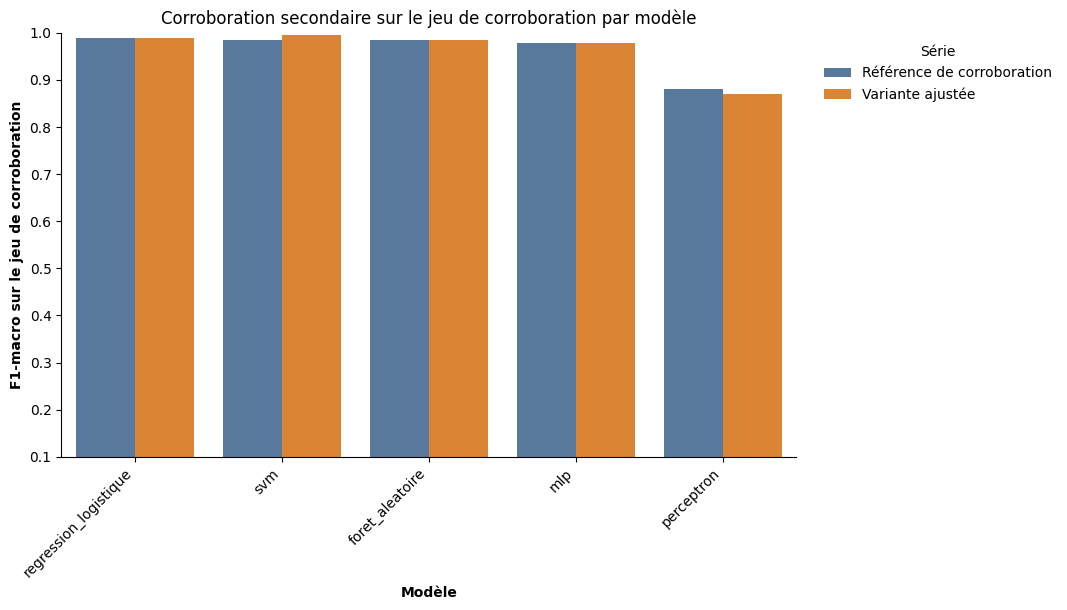

In [10]:
tableau_corroboration_globale = construire_tableau_corroboration_globale(model_names, root=OUTPUT_ROOT)
if tableau_corroboration_globale.empty:
    display(Markdown("_Aucune corroboration sur le jeu de corroboration disponible dans les artefacts canoniques._"))
else:
    tableau_corroboration_globale = tableau_corroboration_globale.sort_values("nested_cv_f1", ascending=False).reset_index(drop=True)
    display(tableau_corroboration_globale.round(4))
    tracer_corroboration_globale(
        tableau_corroboration_globale,
        titre="Corroboration secondaire sur le jeu de corroboration par modèle",
    )
    plt.show()
